# **CA2 Project: Time Series Analysis**
## **Name: Pei Wen Tan (Wendy)**
## **Student ID: D00253240**
## **Dataset: Brent Crude Oil (BZ=F) & MYR/USD Exchange Rate (MYR=X)**
## **Period from 02/01/2018 to 31/12/2024 (7 Years)**

### **Table of Contents**

**[Step 1: Data Description and Acquisition](#step-1-data-description-and-acquisition)**

**[Step 2: Exploratory Data Analysis (EDA)](#step-2-exploratory-data-analysis-eda)**
- [2.1 Visualization of Raw Time Series](#21-visualization-of-raw-time-series)
- [2.2 Rolling Statistics of Mean and Standard Deviation](#22-rolling-statistics-of-mean-and-standard-deviation)
- [2.3 Classical and STL Decomposition](#23-classical-and-stl-decomposition)
    - [2.3.a Classical Decomposition](#23a-classical-decomposition)
    - [2.3.b STL Decomposition](#23b-stl-decomposition)
- [2.4 Distribution and Correlation](#24-distribution-and-correlation)   


**[Step 3: Methodology](#step-3-methodology)**
- [3.1 Stationarity Tests](#31-stationarity-tests)
    - [3.1.a Stationarity Tests using ADF and KPSS](#31a-stationarity-tests-using-adf-and-kpss)
    - [3.1.b Visualization of Original vs First-Differenced Series](#31b-visualization-of-original-vs-first-differenced-series)
- [3.2 Modelling and Model Selection](#32-modelling-and-model-selection)
    - [3.2.a ACF and PACF Analysis](#32a-acf-and-pacf-analysis)
    - [3.2.b Auto ARIMA using AIC Grid Search](#32b-auto-arima-using-aic-grid-search)
    - [3.2.c ARIMA Model Selection: Comparison of Box-Jenkins vs Auto ARIMA](#32c-arima-model-selection-comparison-of-box-jenkins-vs-auto-arima)
    - [3.2.d SARIMA Model Selection: Comparison of Box-Jenkins vs Auto SARIMA](#32d-sarima-model-selection-comparison-of-box-jenkins-vs-auto-sarima)

**[Step 4: Diagnostics](#step-4-diagnostics)**
- [4.1 Model Comparison based on AIC and BIC](#41-model-comparison-based-on-aic-and-bic)
- [4.2 Interpretation of Summaries of Final Selected Models](#42-interpretation-of-summaries-of-final-selected-models)
- [4.3 Residual Diagnostics](#43-residual-diagnostics)
- [4.4 Summary of Diagnostics](#44-summary-of-diagnostics)

**[Step 5: Forecasting](#step-5-forecasting)**
- [5.1 Model 1: ARIMA Forecast](#51-model-1-arima-forecast)
- [5.2 Model 2: SARIMA Forecast](#52-model-2-sarima-forecast)
- [5.3 Model 3: FNN Forecast (Keras + Dropout + Early Stopping)](#53-model-3-fnn-forecast-keras--dropout--early-stopping)
- [5.4 Summary of Model Comparison and Forecast Accuracy](#54-summary-of-model-comparison-and-forecast-accuracy)

**[Step 6: Conclusion](#step-6-conclusion)**
- [6.1 Limitations](#61-limitations)
- [6.2 Future Improvements](#62-future-improvements)   

### **Project Overview**

This project analyses two financially interconnected time series:
1. **Brent Crude Oil** is the global oil benchmark which directly impacting Malaysia's GDP, PETRONAS revenue and  its monetary policy decisions of Bank Negara Malaysia which is the the central bank of Malaysia.   
2. **MYR/USD Exchange Rate** is Malaysia's most strategically monitored currency pair managed by Bank Negara Malaysia.  

The analysis covers the full pipeline from data acquisition, EDA, decomposition, stationarity testing, ARIMA/SARIMA modelling and a regularised FNN with dropout and early stopping for 30 day ahead forecasting.

**Libraries Used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`, `pmdarima`, `prophet`, `sklearn`, `tensorflow/keras`, `scipy`  

**Please download the necessary libraries before running the code below**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX   
from statsmodels.tsa.arima.model import ARIMA as ARIMA_SM 
import statsmodels.api as sm
import pmdarima as pm
from pmdarima import auto_arima
from prophet import Prophet
from prophet.plot import plot_plotly
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy import stats

plt.style.use('default')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True,'grid.alpha': 0.3, 'font.size': 11})
selected_colors = {'brent': '#E8593C', 'myr': '#1D9E75', 'forecast': '#534AB7','ci': '#AFA9EC', 'actual': '#2C2C2A'}

print('All libraries imported successfully.')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}, TF: {tf.__version__}')

All libraries imported successfully.
NumPy: 2.2.5, Pandas: 2.3.3, TF: 2.21.0



### **Step 1: Data Description and Acquisition**

Both datasets are sourced from Yahoo Finance via the `yfinance` library.
- **Brent Crude Oil** ticker: `BZ=F` with the Front-month futures and USD per barrel  
- **MYR/USD Exchange Rate** ticker: `MYR=X` with the raw quote is USD per 1 MYR but  inverted to obtain MYR per USD 
- **Frequency:** Daily during the business days
- **Period:** 2018-01-02 to 2024-12-31     

#### **Overview of Dataset**

1.  **Brent Crude Oil**
- **Period:** 21 March 2019 – 20 March 2026  (7 years)
- **Observations:** 1763 daily data points  (7 years)

2. **MYR/USD Exchange Rate**
- **Period:** 21 March 2019 – 20 March 2026  
- **Observations:** 1820 daily data points  

Both datasets exceed the minimum requirement for time series modelling.     
These variables are selected due to their strong relevance to Malaysia’s economic landscape:

1. **Brent Crude Oil Prices**
  - Influence Malaysia’s GDP and government revenue
  - Closely linked to performance of PETRONAS 
  - Impact policy decisions by Bank Negara Malaysia  

2. **MYR/USD Exchange Rate**
  - Most closely monitored currency pair in Malaysia
  - Central to financial operations across major institutions such as:
    - Maybank  
    - CIMB  
    - Public Bank  
    - RHB   

#### **Structure of Dataset**

1. **Dataset 1: Brent Crude Oil**  
- **File Name:** `brent_crude_2019_2026.csv`  
- **Ticker:** `BZ=F`  
- **Observations:** 1827  

| Column | Description | Type |
|--------|------------|------|
| Date   | Format: YYYY-MM-DD (business days only) | Date |
| Brent_USD  | Closing price in USD per barrel (for example 67.83 on 2019-03-21) | Decimal |

2. **Dataset 2: MYR/USD Exchange Rate**  
- **File Name:** `usdmyr_2019_2026.csv`  
- **Ticker:** `MYR=X`  
- **Observations:** 1827  

| Column | Description | Type |
|--------|------------|------|
| Date   | Format: YYYY-MM-DD (business days only) | Date |
| USDMYR  | Raw value represents MYR per 1 USD for example 4.06 which aligns with Bank Negara Malaysia standards | Decimal |


### **The Data Cleaning Steps**

1. **Missing values:** Yahoo Finance returns `NaN` for non-trading days and public holidays. Each series was first review to ensure there is non-null observations via `.dropna()`, then reindexed to business-day (`'B'`) frequency using `.asfreq('B')`. Remaining gaps from exchange-specific holidays were filled by forward-filling (`ffill()`) to carry the last observed price forward.  After this preprocessing step both series contained **no missing values** with a total of **1827 aligned observations in each series**     

2. **Date formatting:** The `Date` column is automatically handled by yfinance and converted into a standard datetime format without any timezone attached. No extra formatting steps were needed. To keep the data consistent it was reindexed to include only business days to ensure there are no gaps in the timeline. 

3. **Outlier detection:** 
- Outliers were identified using the IQR rule by observe if there is any datat points lying beyond 1.5× the IQR below Q1 or above Q3. 
- A total of 87 outliers were detected for Brent crude prices while none were found for MYR/USD.   
- No observations were removed as these values reflect genuine market conditions rather than data errors. 

In [21]:

import yfinance as yf

brent_raw = yf.download('BZ=F',  start='2019-03-21', end='2026-03-21', auto_adjust=True)
myr_raw   = yf.download('MYR=X', start='2019-03-21', end='2026-03-21', auto_adjust=True)

brent_df  = brent_raw[['Close']].dropna()
myr_df    = myr_raw[['Close']].dropna()  

brent_df.columns = ['Brent_USD']
myr_df.columns   = ['USDMYR']

#set the datasets frequency to business day and forward-fill any missing market days
brent_df = brent_df.asfreq('B').ffill()
myr_df   = myr_df.asfreq('B').ffill()  

brent_df.to_csv('brent_crude_2019_2026.csv')
myr_df.to_csv('usdmyr_2019_2026.csv')

print('Brent Crude Oil (USD/barrel)')
print(f'Date range : {brent_df.index.min().date()} to {brent_df.index.max().date()}')
print(f'Observations: {len(brent_df)}')
print(f'Missing values: {brent_df.isna().sum().values[0]}')
print(brent_df.describe().round(2))

print('\n MYR/USD Exchange Rate')
print(f'Date range : {myr_df.index.min().date()} to {myr_df.index.max().date()}')
print(f'Observations: {len(myr_df)}')
print(f'Missing values: {myr_df.isna().sum().values[0]}')
print(myr_df.describe().round(4))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Brent Crude Oil (USD/barrel)
Date range : 2019-03-21 to 2026-03-20
Observations: 1827
Missing values: 0
       Brent_USD
count    1827.00
mean       72.82
std        17.84
min        19.33
25%        63.70
50%        73.19
75%        83.26
max       127.98

 MYR/USD Exchange Rate
Date range : 2019-03-21 to 2026-03-20
Observations: 1827
Missing values: 0
          USDMYR
count  1827.0000
mean      4.3231
std       0.2184
min       3.8820
25%       4.1553
50%       4.2400
75%       4.4625
max       4.7963


Missing Value Check after the ffill
Brent missing : 0
USDMYR missing: 0

 Index dtype
Brent index : datetime64[ns]
USDMYR index: datetime64[ns]
Outlier Detection using the IQR and the 1.5x rule
Brent_USD: Q1=63.7000, Q3=83.2650, IQR=19.5650
 Bounds : [34.3525, 112.6125]
 Flagged outliers: 87

 Outlier prices (Brent_USD):
Date
2020-03-12     33.22
2020-03-13     33.85
2020-03-16     30.05
2020-03-17     28.73
2020-03-18     24.88
2020-03-19     28.47
2020-03-20     26.98
2020-03-23     27.03
2020-03-24     27.15
2020-03-25     27.39
2020-03-26     26.34
2020-03-27     24.93
2020-03-30     22.76
2020-03-31     22.74
2020-04-01     24.74
2020-04-02     29.94
2020-04-03     34.11
2020-04-06     33.05
2020-04-07     31.87
2020-04-08     32.84
2020-04-09     31.48
2020-04-10     31.48
2020-04-13     31.74
2020-04-14     29.60
2020-04-15     27.69
2020-04-16     27.82
2020-04-17     28.08
2020-04-20     25.57
2020-04-21     19.33
2020-04-22     20.37
2020-04-23     21.33
2020-04-24     21.44


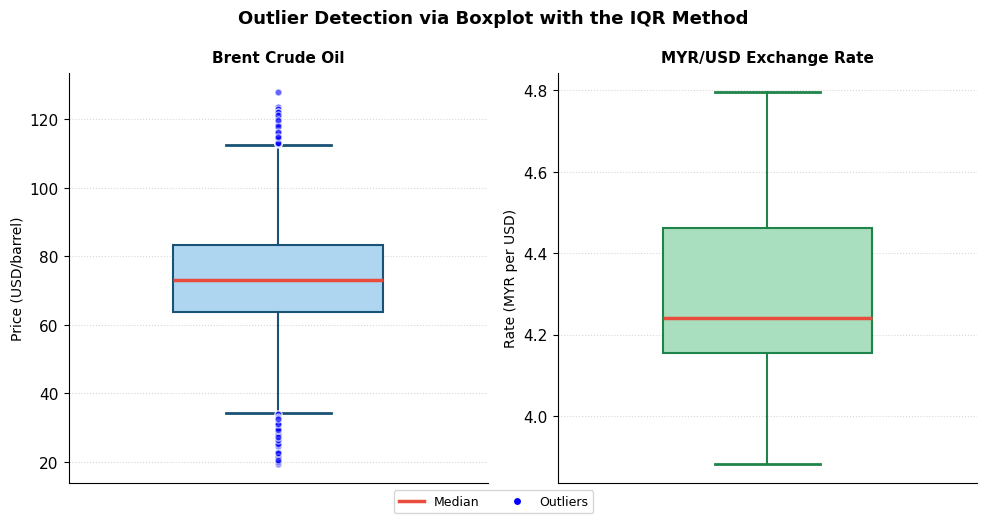

In [22]:
print("Missing Value Check after the ffill")
print(f"Brent missing : {brent_df.isna().sum().values[0]}")
print(f"USDMYR missing: {myr_df.isna().sum().values[0]}")

print("\n Index dtype")
print(f"Brent index : {brent_df.index.dtype}")
print(f"USDMYR index: {myr_df.index.dtype}")

def flag_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1:.4f}, Q3={Q3:.4f}, IQR={IQR:.4f}")
    print(f" Bounds : [{lower:.4f}, {upper:.4f}]")
    print(f" Flagged outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"\n Outlier prices ({col}):")
        print(outliers[col].round(2).to_string())
    return outliers

print("Outlier Detection using the IQR and the 1.5x rule")
brent_outliers = flag_outliers(brent_df, 'Brent_USD')
myr_outliers   = flag_outliers(myr_df,'USDMYR')

print("\n Brent Crude Oil for USD/barrel")
print(f"Date range: {brent_df.index.min().date()} to {brent_df.index.max().date()}")
print(f"Observations: {len(brent_df)}")
print(brent_df.describe().round(2))

print("\n MYR/USD Exchange Rate")
print(f"Date range: {myr_df.index.min().date()} to {myr_df.index.max().date()}")
print(f"Observations: {len(myr_df)}")
print(myr_df.describe().round(4))  


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Outlier Detection via Boxplot with the IQR Method', fontsize=13, fontweight='bold')

datasets = [
    (brent_df['Brent_USD'], axes[0], '#AED6F1', '#1A5276', 'Brent Crude Oil', 'Price (USD/barrel)'),
    (myr_df['USDMYR'],      axes[1], '#A9DFBF', '#1E8449', 'MYR/USD Exchange Rate', 'Rate (MYR per USD)')
]

for series, ax, facecolor, edgecolor, title, ylabel in datasets:
    data = series.dropna()

    ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=facecolor, color=edgecolor, linewidth=1.5),
        medianprops=dict(color='#E74C3C', linewidth=2.5),
        whiskerprops=dict(color=edgecolor, linewidth=1.5),
        capprops=dict(color=edgecolor, linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='blue',
                        markeredgecolor='white', markersize=5, alpha=0.6)
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks([])
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

legend_elements = [
    Line2D([0], [0], color='#E74C3C', linewidth=2.5, label='Median'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markersize=6, label='Outliers'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('C:/Users/user/OneDrive - Dundalk Institute of Technology/Desktop/Dkit/Dkit 2025/Time Series Analysis/CA2_PeiWenTan_D00253240_TSA/plots_figure_results/boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

### **Step 2: Exploratory Data Analysis (EDA)**

#### **2.1 Visualization of Raw Time Series**  

Figure 1 displays the daily closing prices for both Brent Crude Oil (USD/barrel) and the MYR/USD Exchange Rate over the full study period from 21 March 2019 to 20 March 2026. Two major geopolitical events are annotated across both series to contextualise the structural breaks observed throughout the data.

**Brent Crude Oil**

Brent Crude prices opened the study period at approximately $67 per barrel in March 2019, fluctuating within a relatively stable range of $55 to $75 per barrel through early 2020. The first annotated event is the **Initial Shock of COVID-19** highlighted by the red shaded region at March 2020 to May 2020 triggered by the most dramatic price collapse in the dataset, with Brent falling sharply to a minimum of $19.33 per barrel in April 2020. This dual shock was driven by the simultaneous collapse in global oil demand from worldwide lockdowns and the geopolitical oil price war. 

Following the COVID-19 trough, prices recovered steadily through 2020–2021 as vaccine rollouts and OPEC+ production cuts supported demand. The second annotated event is the **Russia–Ukraine War spike** highlighted by the yellow shaded region from February to June 2022 drove Brent to a 14-year high of of $127.98 per barrel in March 2022. Prices declined through the second half of 2022 and stabilised in the $70 to $90 per barrel range through 2023 to 2025. A notable sharp spike is visible in early 2026, rising from approximately $60 to over $110 per barrel within a short window which is corresponding to a fresh geopolitical shock at the tail end of the study period.

**MYR/USD Exchange Rate**

The MYR/USD rate opened at approximately 4.05 in March 2019, reflecting a relatively stable exchange rate environment. The **COVID-19 shock** highlighted by the red shaded region, March–May 2020 caused a brief MYR weakening to approximately 4.35. The rate subsequently stabilised around 4.15–4.25 through
2020–2021.

The **Federal Reserve rate hike cycle** highlighted by the purple shaded region marked February
2022 to January 2023 the most sustained period of MYR depreciation in the dataset. As the US Federal Reserve aggressively raised interest rates to combat inflation the USD strengthened broadly, pushing MYR/USD to a peak of approximately 4.75 in late 2023 which is the highest level in the study period.
From 2024 onward, the MYR recovered progressively as rate hike expectations eased with the rate declining sharply toward approximately 3.88 by early 2026 which has its lowest level in the full 7 year study period.

**Key Observations**

Both series exhibit clear non-stationarity and neither fluctuates around a fixed mean over the study period, confirming the need for differencing prior to ARIMA modelling. The two series also display a moderate degree of co-movement particularly during 2022–2023 when both Brent prices and the MYR/USD rate were simultaneously elevated. The geopolitical events identified in this visualisation serve as important reference points for interpreting the residual anomalies and forecast deviations observed in
subsequent sections.    



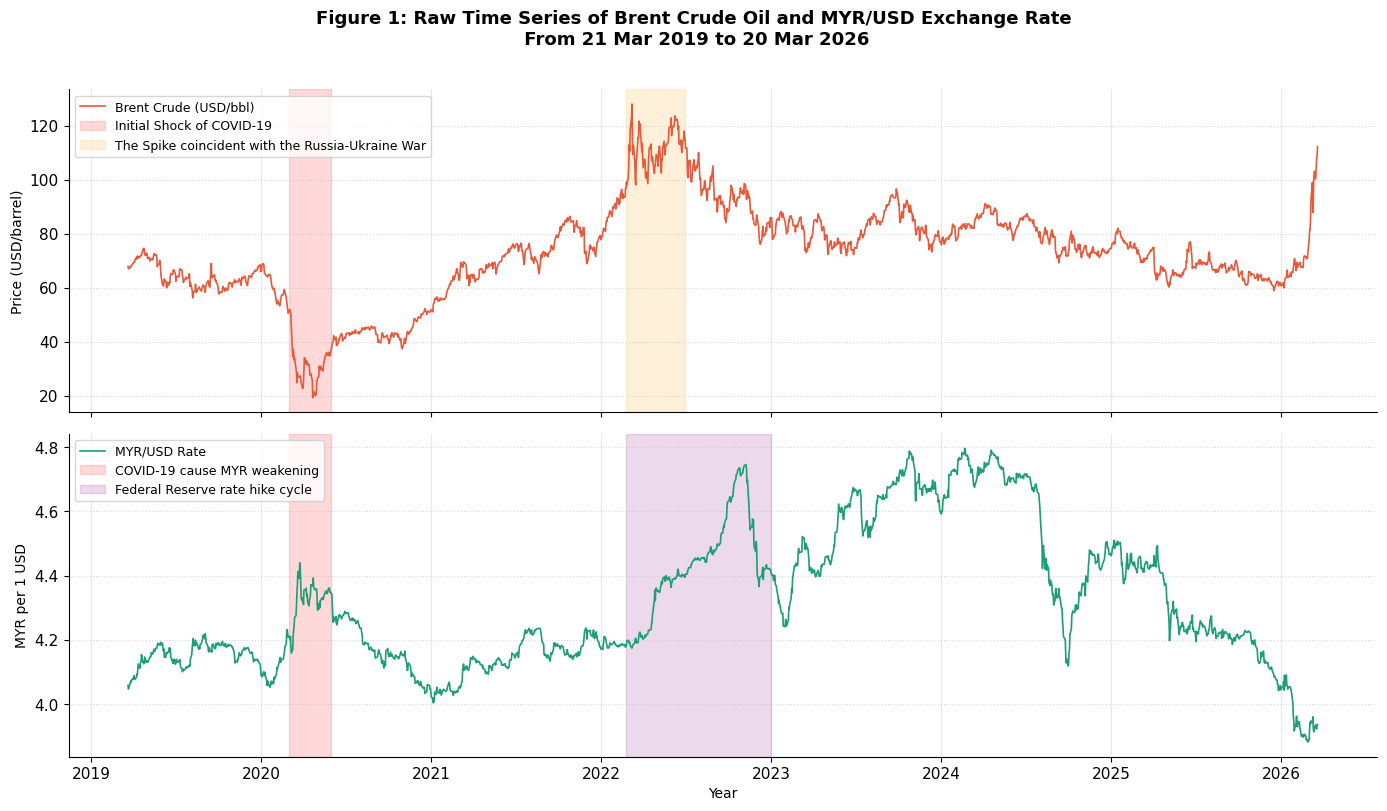

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Figure 1: Raw Time Series of Brent Crude Oil and MYR/USD Exchange Rate\n From 21 Mar 2019 to 20 Mar 2026',
fontsize=13, fontweight='bold', y=1.01)
axes[0].plot(brent_df.index, brent_df['Brent_USD'], color=selected_colors['brent'], linewidth=1.2, label='Brent Crude (USD/bbl)')
axes[0].set_ylabel('Price (USD/barrel)', fontsize=10)
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-05-31'), alpha=0.15, color='red',   label='Initial Shock of COVID-19')
axes[0].axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-06-30'), alpha=0.15, color='orange', label='The Spike coincident with the Russia-Ukraine War')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(myr_df.index, myr_df['USDMYR'], color=selected_colors['myr'], linewidth=1.2, label='MYR/USD Rate')
axes[1].set_ylabel('MYR per 1 USD', fontsize=10)
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-05-31'), alpha=0.15, color='red',    label='COVID-19 cause MYR weakening')
axes[1].axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2023-01-01'), alpha=0.15, color='purple', label='Federal Reserve rate hike cycle')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Year', fontsize=10)
plt.tight_layout()
plt.savefig('C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\fig_01_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()


#### **2.2 Rolling Statistics of Mean and  Standard Deviation**

A 30-day rolling mean and standard deviation are computed to visually assess trend and volatility changes over time.  


#### Interpretation of the Rolling Statistics Figures 

**Figure 2a: Brent Crude Oil**

The 30 day rolling mean reveals a sharp downward trend beginning in early 2020, where
prices fell from approximately $70 per barrel to a low of around $25 per barrel which coinciding with major global events like  COVID-19 pandamic and the oil price war between Saudi Arabia and Russia. Prices then recovered steadily through 2021 before peaking at approximately $115 per barrel in the mid of 2022. From late 2022 onward, the rolling mean stabilised in approximate range of $70 to $85 per barrel before a notable spike re-emerges in early 2026. The rolling standard deviation show these events with the largest volatility spikes occurring in March–April 2020 with approximate standard deviation of 13 and again in mid-2022 with standard deviation of 11 confirming that both periods were characterised by unusually high price instability.    

**Figure 2b MYR/USD Exchange Rate**

The rolling mean indicates that the Malaysian Ringgit (MYR) gradually depreciated against the USD moving from approximately 4.05 in 2019 to a notable spike near 4.35 in early 2020 coinciding with the initial global market disruptions from the COVID-19 pandemic. The exchange rate continued to rise through 2022 and 2023 reaching a peak of around 4.75 reflecting a period of US Federal Reserve’s interest rate increases. From late 2024 onward, the MYR showed recovery declining toward 3.90 by early 2026. The rolling standard deviation highlights moderate but recurring volatility over the period. The largest fluctuations occurred in early 2020 with a standard deviation of approximately 0.10 and again in late 2022 through early 2023 with a standard deviation near 0.13.   


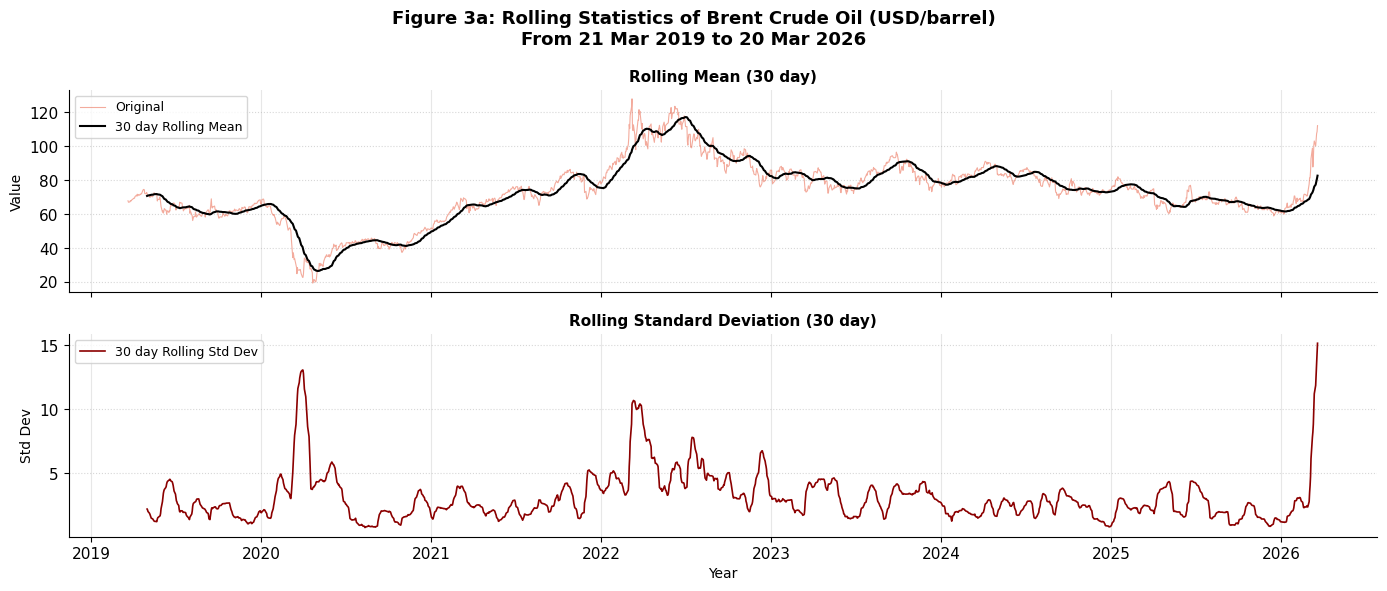

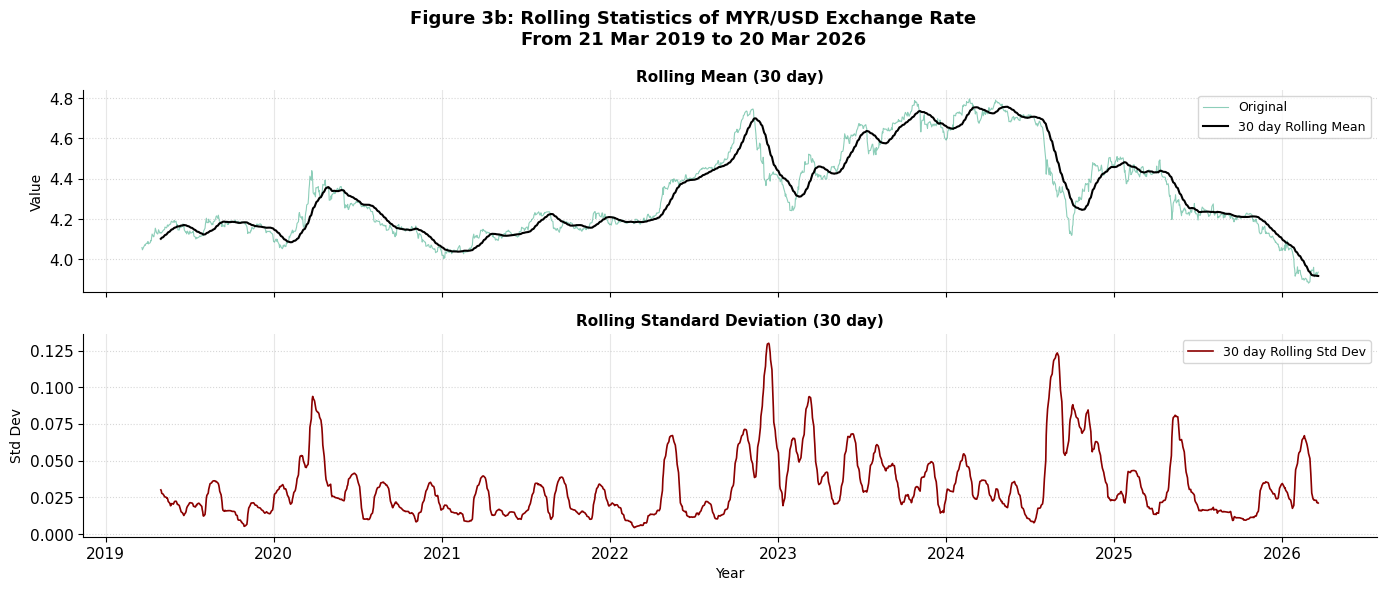

In [24]:
def plot_rolling_stats(series, label, color, window=30, figname='fig'):
    roll_mean = series.rolling(window=window).mean()
    roll_std  = series.rolling(window=window).std()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'{label}\nFrom 21 Mar 2019 to 20 Mar 2026',
                 fontsize=13, fontweight='bold')
    
    axes[0].plot(series, color=color, linewidth=0.8, alpha=0.5, label='Original')
    axes[0].plot(roll_mean, color='black', linewidth=1.5, label=f'{window} day Rolling Mean')
    axes[0].set_title(f'Rolling Mean ({window} day)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Value', fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='y', linestyle=':', alpha=0.5)
    axes[0].spines[['top', 'right']].set_visible(False)

    axes[1].plot(roll_std, color='darkred', linewidth=1.2, label=f'{window} day Rolling Std Dev')
    axes[1].set_title(f'Rolling Standard Deviation ({window} day)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Std Dev', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis='y', linestyle=':', alpha=0.5)
    axes[1].spines[['top', 'right']].set_visible(False)

    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xlabel('Year', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_rolling_stats(brent_df['Brent_USD'], 'Figure 3a: Rolling Statistics of Brent Crude Oil (USD/barrel)',
                   selected_colors['brent'], figname='fig_03a_brent_rolling')

plot_rolling_stats(myr_df['USDMYR'], 'Figure 3b: Rolling Statistics of MYR/USD Exchange Rate',
                   selected_colors['myr'], figname='fig_03b_myr_rolling')

#### **2.3 Classical and STL Decomposition**

Both Classical (additive) and STL decomposition are applied to separate trend, seasonality and residual components.The series are resampled to weekly frequency for decomposition to reveal clearer seasonal patterns.      

#### **2.3.a Classical Decomposition**  

Classical additive decomposition is applied to both series resampled at weekly frequency with the (`period=52`) to separate the observed data into trend, seasonality and residual components.

**Figure of Brent Crude Oil**

1. **The trend component** shows a clear decline from approximately of $65 per barrel in early 2019 to a trough of around $43 per barrel in mid-2020, which coinciding with major global events like the COVID-19 pandamic. The trend then recovered sharply through 2021 to 2022 peaking near around $97 per barrel before gradually declining toward around $68 per barrel by early 2026.  

2. **The seasonal component** oscillates consistently between approximately −$4 and +$4, indicating a weak but recurring intra-year price cycle. 

3. **The residual component** reveals two prominent spikes with a large negative deviation in early 2020 around −$22 and a positive spike in mid 2022 with around +$20 both corresponding to the documented geopolitical and pandemic shocks that could not be explained by trend or seasonality alone.   

**Figure of MYR/USD Exchange Rate**

1. **The trend component** shows the MYR depreciated gradually from approximately 4.15 in 2019 dropping slightly in 2021 before rising steeply to a peak of around 4.68 in late 2023 which driven by the US Federal Reserve's aggressive rate hike cycle. The trend has since reversed declining toward 4.20 by early 2026 as rate pressures eased. 

2. **The seasonal component** exhibits a consistent periodic pattern moving between approximately −0.075 and +0.050 therefore suggesting a mild but repeating fluctuations of intra-year exchange rate.   

3. **The residual component** is largely small and centred around zero, with two notable exceptions which are the negative deviation in early 2020 due to COVID-19 pandamic and a sharp negative spike around middle of 2024 with approximately−0.30 indicating a sudden MYR strengthening episode which are not explained by the trend or seasonal pattern.  


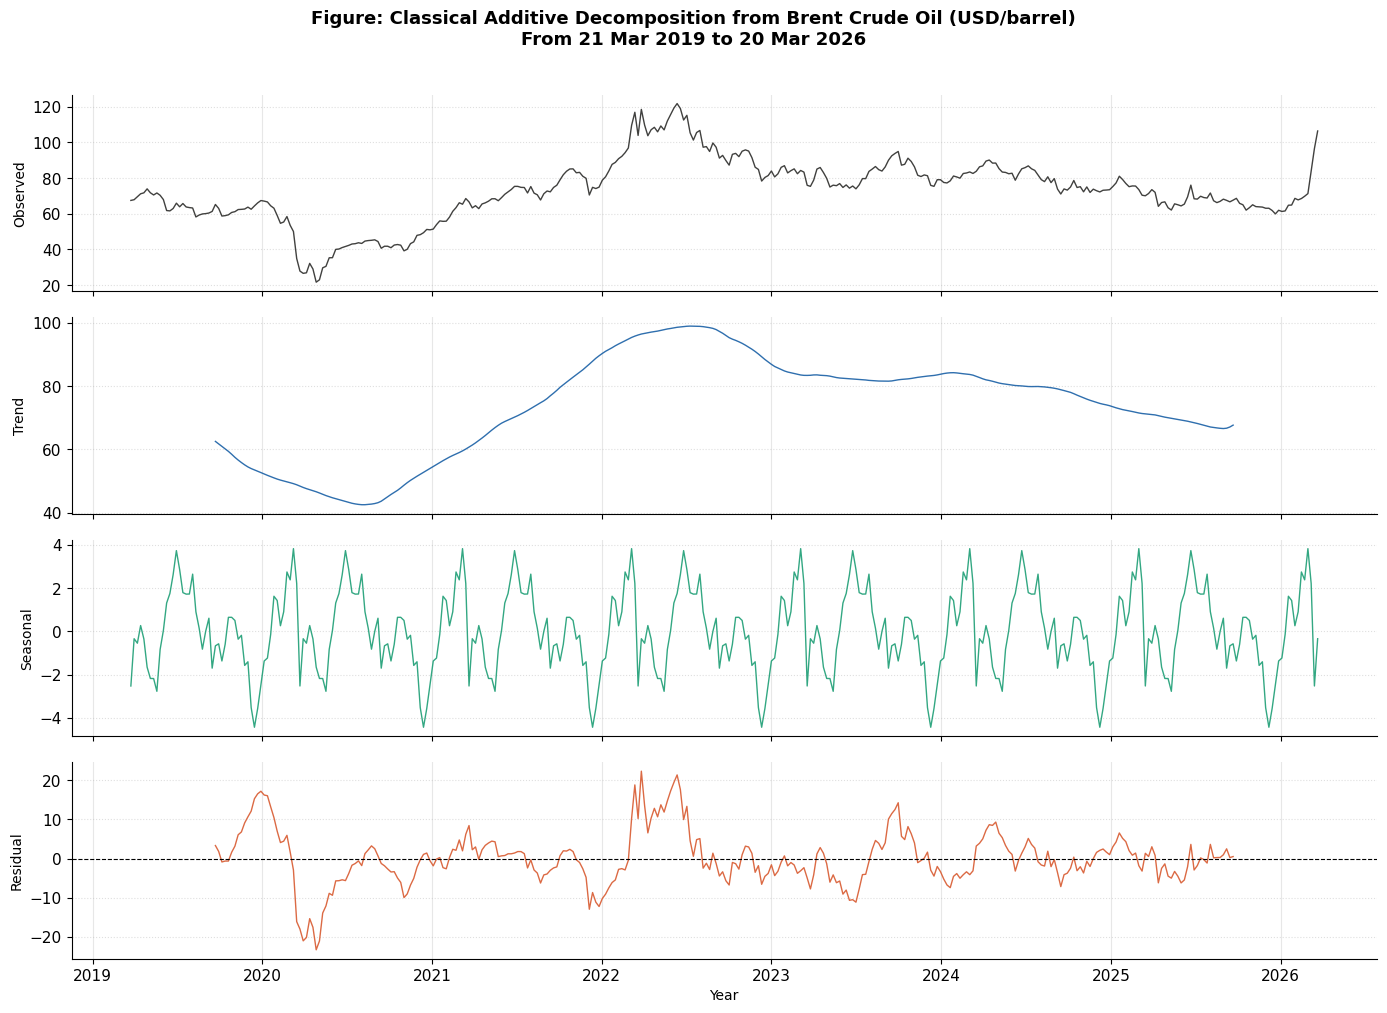

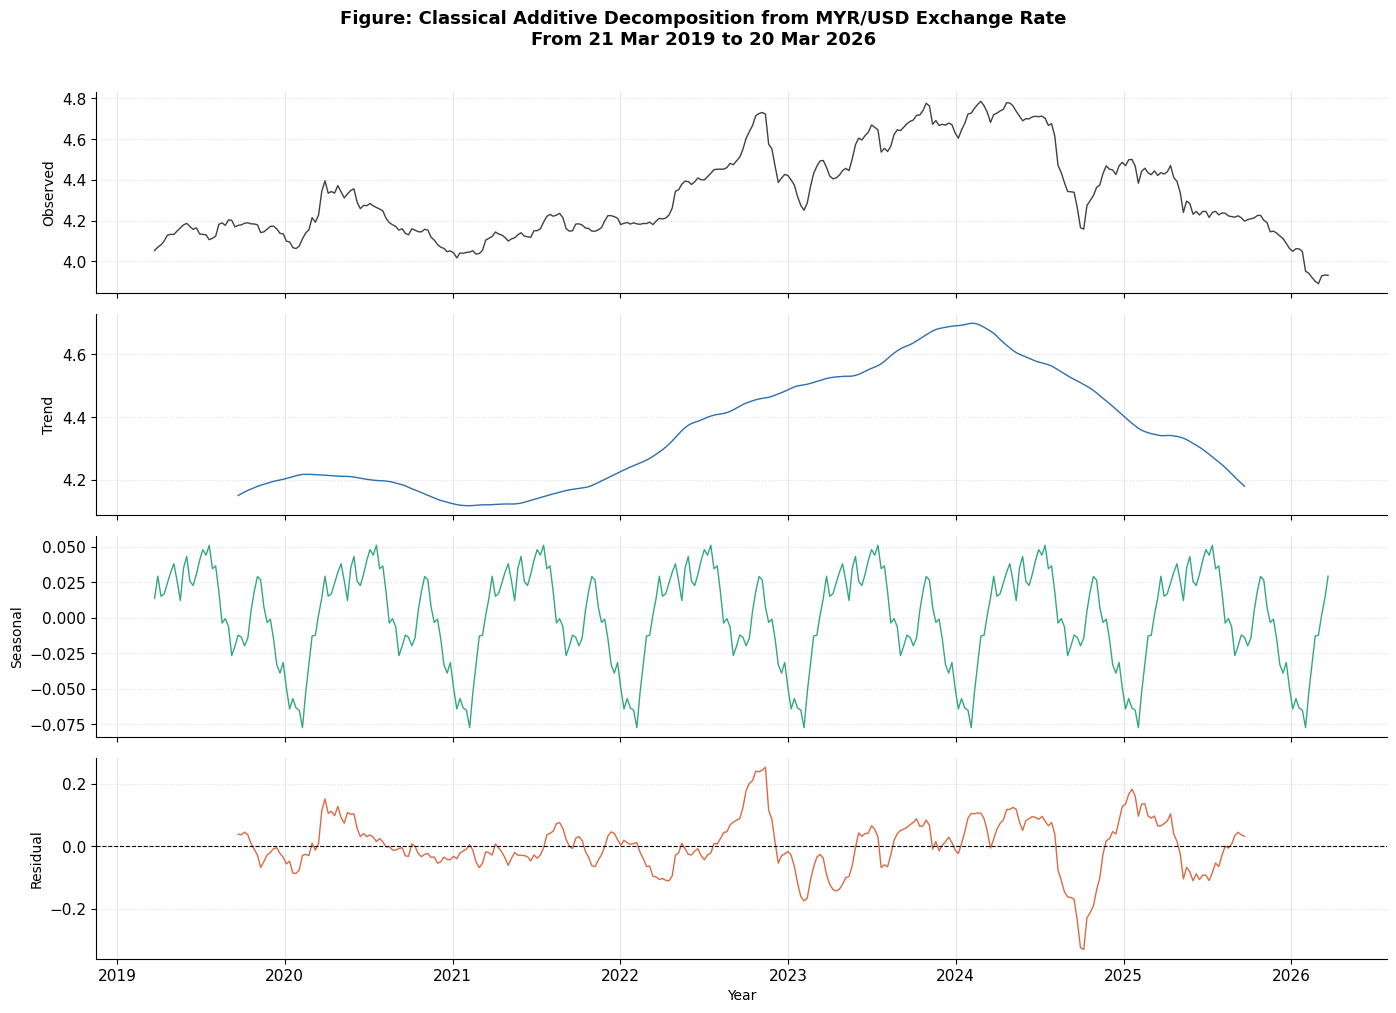

In [25]:
def classical_decompose(series, label, period, figname):
    result = seasonal_decompose(series, model='additive', period=period)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Figure: Classical Additive Decomposition from {label}\nFrom 21 Mar 2019 to 20 Mar 2026',
                 fontsize=13, fontweight='bold', y=1.01)

    components = [
        (result.observed, 'Observed',  '#2C2C2A'),
        (result.trend,    'Trend',     '#185FA5'),
        (result.seasonal, 'Seasonal',  '#1D9E75'),
        (result.resid,    'Residual',  '#D85A30'),
    ]

    for ax, (data, label_comp, color) in zip(axes, components):
        ax.plot(data, color=color, linewidth=1.0, alpha=0.9)
        if label_comp == 'Residual':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylabel(label_comp, fontsize=10)
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xlabel('Year', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return result

# Resample to weekly with the classical decomposition requires period to divide evenly into the series
brent_weekly = brent_df['Brent_USD'].resample('W').mean().dropna()
myr_weekly   = myr_df['USDMYR'].resample('W').mean().dropna()

decomp_brent = classical_decompose(brent_weekly, 'Brent Crude Oil (USD/barrel)',period=52, figname='fig_03a_brent_decomp')

decomp_myr   = classical_decompose(myr_weekly, 'MYR/USD Exchange Rate', period=52, figname='fig_03b_myr_decomp')

#### **2.3.b STL Decomposition**    

STL (Seasonal and Trend decomposition using Loess) with `robust=True` is applied to both series at weekly frequency (`period=52`) to separate the observed data into trend, seasonality and residual components. Unlike Classical decomposition, STL uses a fitting procedure that reduces the influence of extreme outliers on the trend and seasonal estimates.

**Figure of Brent Crude Oil**   

1. **The STL trend component** shows a smoother and more complete estimate compared to the Classical decomposition  with the starting at approximately $70 per barrel in 2019 declining to around $55 per barrel in middle of 2020 then recovering steadily to a peak of approximately $87 per barrel in the middle of 2022 before gradually declining to around $62 per barrel by early 2026. Notably, the trend does not spike as sharply as the Classical result during the 2022 global events (Ukraine war period) because of the `robust=True` prevents the extreme price observations from distorting the trend estimate. 

2. **The seasonal component** moving between approximately −$6 and +$9 showing slightly wider amplitude than the Classical result reflecting more flexible seasonal estimation by Loess smoothing. 

3. **The residual component** captures the large negative shock in early 2020 with arounf −$28 and a large positive spike the in middle of 2022 approximately +$40  isolating these genuine anomalies more cleanly than the Classical method.  

**MYR/USD Exchange Rate (Figure 4b)**

1. **The STL trend** starts at approximately 4.10 in 2019 which remains relatively stable through 2020 to 2021 then rises steeply to a peak of around 4.68 in late 2023 before declining sharply to approximately 3.90 by early 2026. 

2. **The seasonal component** moving between approximately −0.10 and +0.10 which is slightly wider than the Classical result again reflecting STL is more adaptive seasonal fitting. 

3. **The residuals components** remain close to zero for most of the period indicating that the trend and seasonal components explain the majority of the variation. However, two notable deviations are observed which is a positive spike of approximately +0.28 in early 2023 and a sharp negative spike of around −0.45 in mid-2024. The latter suggests a brief episode of rapid MYR increase that is not captured by the underlying trend or seasonal pattern and is more distinctly isolated by the STL decomposition.  


**Key differences between Classical and STL Decomposition**

| Aspect | Classical Decomposition | STL Decomposition |
|--------|------------------------|-------------------|
| Trend estimation | Centred moving average which leaves NaN at both ends of the series | Loess smoothing therefore produces a complete trend across the full series |
| Seasonal component | Fixed and identical each year | Allowed to evolve slowly over time |
| Outlier handling | Sensitive with extreme values that could possibly distort trend and seasonal estimates | Robust using `robust=True` downweights outliers during the fitting |
| Residual | Captures less of the spike due to outlier leakage into trend | Isolates spikes more cleanly into the residual component |
| Flexibility | Less flexible but simpler to interpret | More flexible but better suited for long series with fluctuates  patterns |

**Conclusion**   
Based on this study, STL is the preferred decomposition method as the 7 year time series contains
two significant structural shocks which are coinciding with major global events like the COVID-19 pandamic and geoppolitical oil price war that could distort results under classical decomposition.  


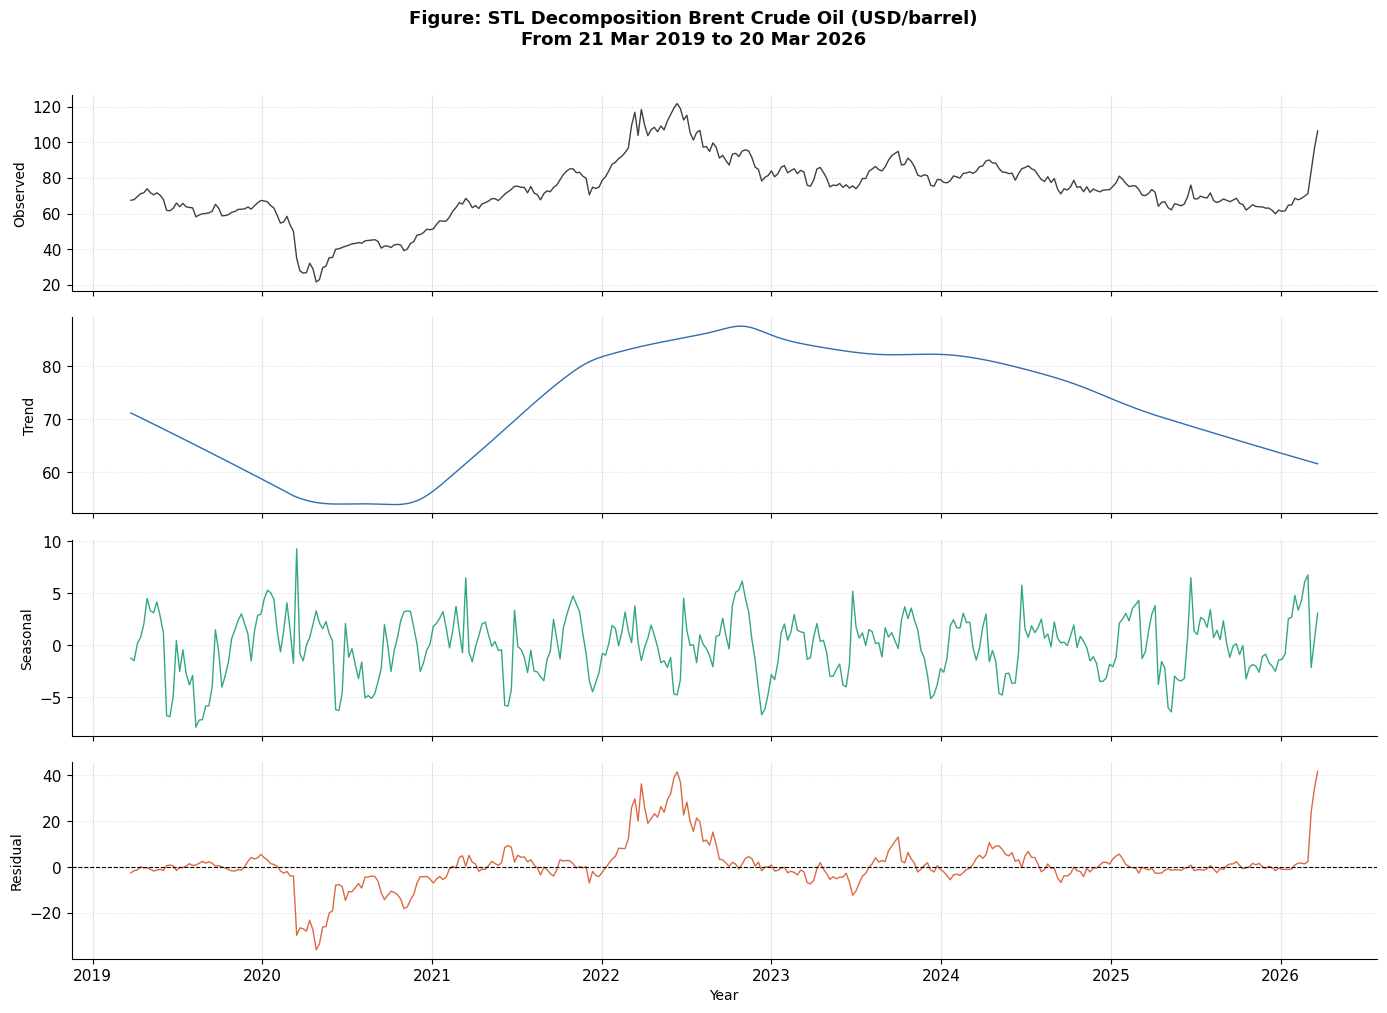

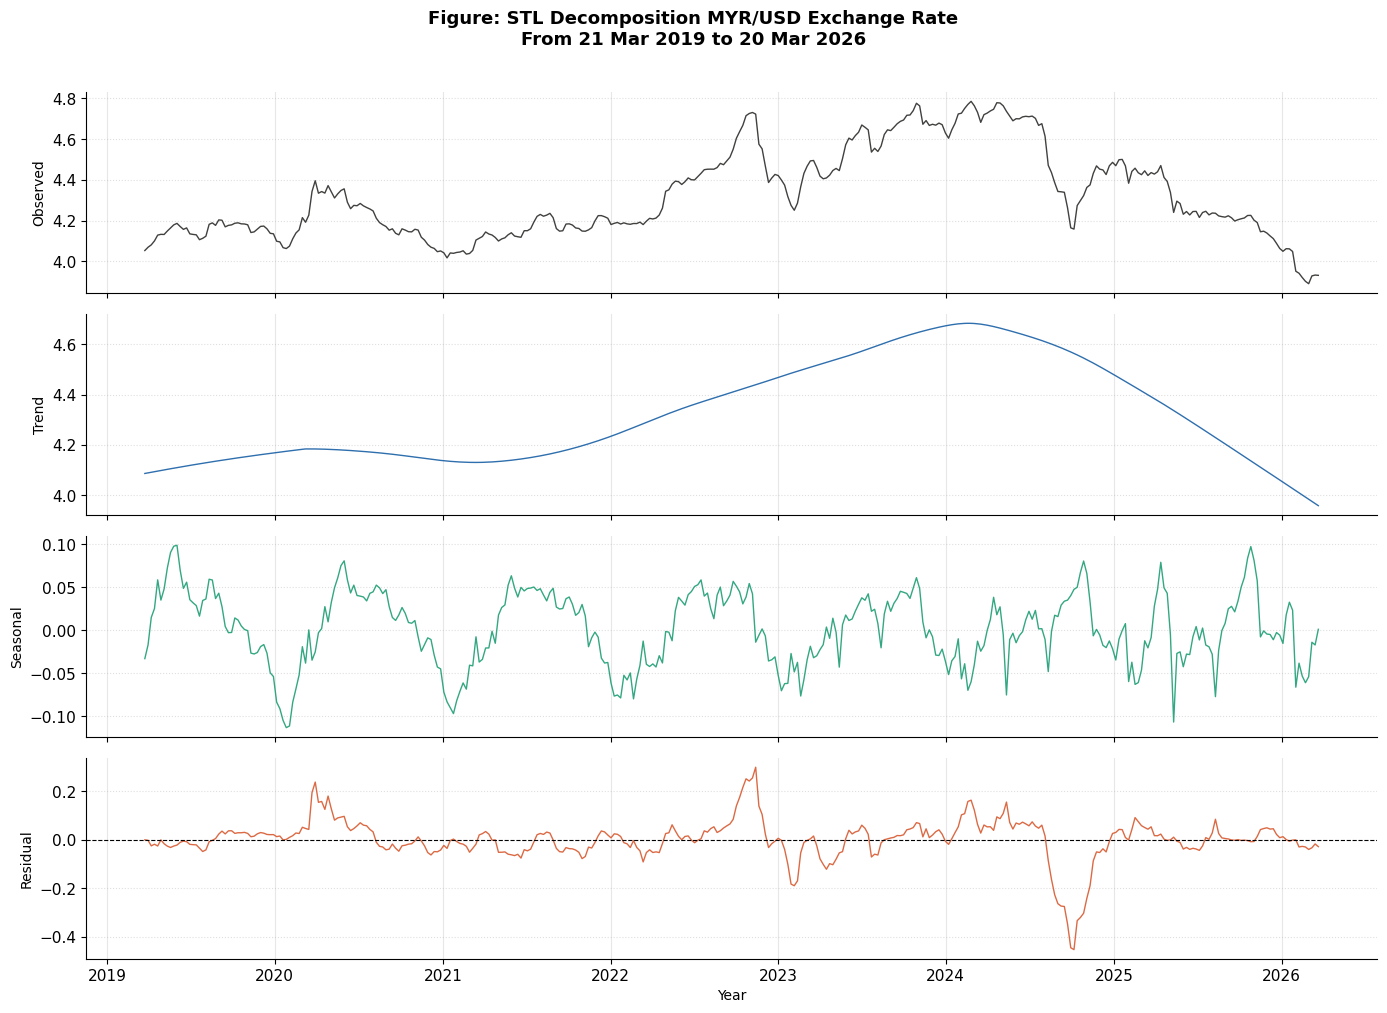

In [26]:
def stl_decompose(series, label, period, figname):
    stl    = STL(series, period=period, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Figure: STL Decomposition {label}\nFrom 21 Mar 2019 to 20 Mar 2026',
                 fontsize=13, fontweight='bold', y=1.01)
    components = [
        (result.observed, 'Observed', '#2C2C2A'),
        (result.trend,    'Trend',    '#185FA5'),
        (result.seasonal, 'Seasonal', '#1D9E75'),
        (result.resid,    'Residual', '#D85A30'),]

    for ax, (data, label_comp, color) in zip(axes, components):
        ax.plot(data, color=color, linewidth=1.0, alpha=0.9)
        if label_comp == 'Residual':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylabel(label_comp, fontsize=10)
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xlabel('Year', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return result

# brent_weekly and myr_weekly
stl_brent = stl_decompose(brent_weekly, 'Brent Crude Oil (USD/barrel)', period=52, figname='fig_04a_brent_stl')

stl_myr   = stl_decompose(myr_weekly,   'MYR/USD Exchange Rate',period=52, figname='fig_04b_myr_stl')

#### **2.4 Distribution and Correlation**   


**Brent Crude Oil Price Distribution**

The distribution of Brent Crude Oil prices is broadly spread across the range of
approximately $19 to $128 per barrel with the highest concentration of observations
between $60 and $85 per barrel which is consistent with the descriptive statistics showing a mean of $72.82 and median of $73.19 per barrel. The distribution is slightly left-skewed with a visible secondary cluster of lower frequency observations below $45 per barrel which is corresponding to the COVID-19 price collapse period in 2020. The spread across a wide price range reflects the high volatility of Brent Crude over the 7 year study period driven by the two major geopolitical shocks identified in previous sections 

**MYR/USD Exchange Rate Distribution**

The MYR/USD distribution shows a bimodal pattern with two distinct concentration areas with a primary peak around 4.10 to 4.20 MYR per USD and a secondary peak around 4.40 4.75 MYR per USD. This bimodality reflects two distinct exchange rate regimes within the study period which is the pre 2022 period where the MYR traded in the 4.00 to 4.30 range, and the post 2022 period where the MYR weakened significantly toward 4.40 to 4.80 driven by the US Federal Reserve rate hike cycle. The distribution ranges from approximately 3.88 to 4.80 MYR per USD consistent with the descriptive statistics in previous sections 

**Brent vs MYR/USD Correlation**

The Pearson correlation coefficient between Brent Crude Oil prices and the MYR/USD
exchange rate is **r = 0.417** indicating a **moderate positive correlation**. This
means that higher Brent prices tend to be associated with a weaker MYR or higher MYR
per USD value. However, the scatter plot reveals that the relationship is far from
linear becasue the cloud of points is widely dispersed particularly at mid-range Brent
prices with $60 to $90 per barrel suggesting that other macroeconomic factors such as interest rate differentials, global risk sentiment or capital flows also significantly influence the MYR/USD rate beyond oil prices alone.

The moderate positive correlation is economically intuitive for Malaysia as a net
oil exporter, higher Brent prices should theoretically strengthen the MYR. However,
the positive correlation observed here the higher the Brent meaning the weaker MYR  suggests the presence of stronger external forces. In particular, the broad strengthening of the USD during the 2022to 2023 Federal Reserve rate hike cycle coincided with elevated Brent prices which ultimately offsetting the expected oil-export advantage and exerting downward pressure on the MYR during this period.

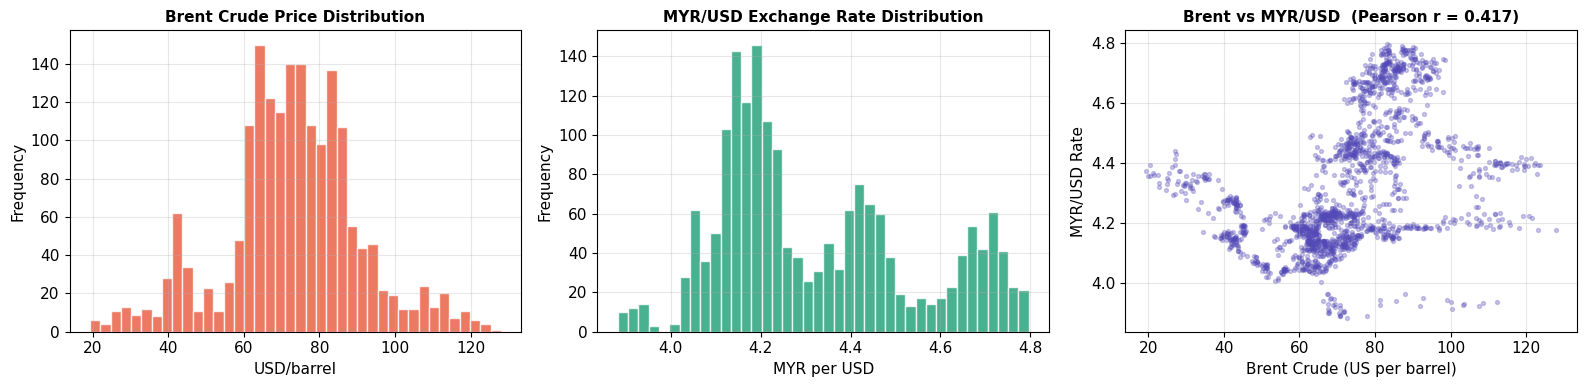

Pearson Correlation (Brent vs MYR/USD): 0.4171


In [27]:
combined = pd.concat([brent_df['Brent_USD'], myr_df['USDMYR']], axis=1).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(combined['Brent_USD'], bins=40, color=selected_colors['brent'], edgecolor='white', alpha=0.8)
axes[0].set_title('Brent Crude Price Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('USD/barrel')
axes[0].set_ylabel('Frequency')

axes[1].hist(combined['USDMYR'], bins=40, color=selected_colors['myr'], edgecolor='white', alpha=0.8)
axes[1].set_title('MYR/USD Exchange Rate Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('MYR per USD')
axes[1].set_ylabel('Frequency')

axes[2].scatter(combined['Brent_USD'], combined['USDMYR'],
                alpha=0.3, s=8, color='#534AB7')
corr = combined.corr().loc['Brent_USD', 'USDMYR']
axes[2].set_title(f'Brent vs MYR/USD  (Pearson r = {corr:.3f})', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Brent Crude (US per barrel)')
axes[2].set_ylabel('MYR/USD Rate')

plt.tight_layout()
plt.savefig('C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\fig_03_distribution_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson Correlation (Brent vs MYR/USD): {corr:.4f}')

### **Step 3: Methodology**  

#### **3.1 Stationarity Tests**


#### **3.1.a Stationarity Tests using ADF & KPSS**

To determine whether each series requires differencing before modelling two complementary stationarity tests are applied which are the Augmented Dickey-Fuller (ADF) test and the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test. 

**The ADF test has a null hypothesis of non-stationarity meaning the presence of unit root present.**      

**ADF Test (Augmented Dickey-Fuller)**
1. Null hypothesis: The series is non-stationary (has a unit root).  
- If p-value >= 0.05 then fail to reject Null hypothesis conclude non-stationary  
2. Alternative hypothesis: The series is stationary.  
- If p-value < 0.05 then reject Null hypothesis conclude stationary
 
**The KPSS test has a null hypothesis of stationarity.**  
1. Null hypothesis: The series is stationary
- If p-value >= 0.05 then fail to reject Null hypothesis conclude stationary   
2. Alternative hypothesis: The series is non-stationary
- If p-value < 0.05 then reject null hypothesis conclude non-stationary  

A series is confirmed stationary only when both tests agree that is ADF rejects its null with p < 0.05 and KPSS fails to reject its null with p > 0.05.

**Original Series**

Both Brent Crude Oil and MYR/USD fail both tests on their original levels confirming
non-stationarity:

| Series | ADF Statistic | ADF p-value | KPSS Statistic | KPSS p-value | Conclusion |
|--------|--------------|-------------|----------------|--------------|------------|
| Brent Crude Oil (Original)| −1.5663| 0.5005 | 1.7582 | 0.0100 | Non-stationary |
| MYR/USDRate (Original) | −1.4435 | 0.5613 | 1.9953 | 0.0100 | Non-stationary |

1. The ADF p-values of 0.50 and 0.56 are greather than 0.05 threshold therefore it both fail to reject null hypothesis conclude that both are Non-staionary. 

2. The KPSS p value of 0.0100 on both Brent crude oil and MYR/USDrate is below 0.05 therefore reject the null hypothesis conclude that both are non stationary . 

3. Both tests showed that neither series is stationary in its original form indicating the presence of a stochastic trend.

**After First Differencing**   

First differencing is applied to both series to remove the trend and stabilise the mean. Both series become stationary after one round of differencing:

| Series | ADF Statistic | ADF p-value | KPSS Statistic | KPSS p-value | Conclusion |
|--------|--------------|-------------|----------------|--------------|------------|
| Brent Crude Oil after 1st Diff | −8.9634 | 0.0000 | 0.1134 | 0.1000 | Stationary |
| MYR/USDRate after 1st Diff | −19.0327 | 0.0000 | 0.3071 | 0.1000 | Stationary |

1. The ADF p-values of 0.0000 on Brent crude oil and MYR/USDrate are lower than 0.05 threshold therefore it both reject null hypothesis conclude that both are Staionary. 

2. The KPSS p value of 0.0100 on Brent crude oil and MYR/USDrate which is above 0.05 therefore fail to reject the null hypothesis conclude that both are Stationary . 

3. Both tests after the first-differenced series are now stationary confirming that **d = 1** is the appropriate order of integration for both series in the framework of ARIMA. 


In [28]:
def stationarity_test(series, label):
    print(f'Stationarity Tests:{label}')

    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f'\nAugmented Dickey-Fuller (ADF) Test:')
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'p-value: {adf_result[1]:.4f}')
    print(f'Critical Values:')
    for key, val in adf_result[4].items():
        print(f'{key}: {val:.4f}')
    print(f'Result: {"Stationary" if adf_result[1] < 0.05 else "Non-stationary"}')

    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'\nKwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:')
    print(f'KPSS Statistic: {kpss_result[0]:.4f}')
    print(f'p-value: {kpss_result[1]:.4f}')
    print(f'Critical Values:')
    for key, val in kpss_result[3].items():
        print(f'{key}: {val:.4f}')
    print(f'Result: {"Stationary" if kpss_result[1] > 0.05 else "Non-stationary"}')
    print()

stationarity_test(brent_df['Brent_USD'], 'Original Brent Crude Oil')
stationarity_test(myr_df['USDMYR'],'Original MYR/USDExchange Rate')

brent_diff = brent_df['Brent_USD'].diff().dropna()
myr_diff   = myr_df['USDMYR'].diff().dropna()

stationarity_test(brent_diff, 'Brent Crude Oil after 1st Difference')
stationarity_test(myr_diff, 'MYR/USDExchange Rate after 1st Difference')

Stationarity Tests:Original Brent Crude Oil

Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -1.5663
p-value: 0.5005
Critical Values:
1%: -3.4340
5%: -2.8631
10%: -2.5676
Result: Non-stationary

Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
KPSS Statistic: 1.7582
p-value: 0.0100
Critical Values:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Result: Non-stationary

Stationarity Tests:Original MYR/USDExchange Rate

Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -1.4435
p-value: 0.5613
Critical Values:
1%: -3.4339
5%: -2.8631
10%: -2.5676
Result: Non-stationary

Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
KPSS Statistic: 1.9953
p-value: 0.0100
Critical Values:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Result: Non-stationary

Stationarity Tests:Brent Crude Oil after 1st Difference

Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -8.9634
p-value: 0.0000
Critical Values:
1%: -3.4340
5%: -2.8631
10%: -2.5676
Result: Stationary

Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test

#### **3.1.b Visualize Original vs 1st Difference Series**     

Figure 5 compares the original and first-differenced series for both Brent Crude Oil and the MYR/USD exchange rate to show the effect of differencing on stationarity.

**Brent Crude Oil**

The original series located at the top-left exhibits a clear non-stationary trend and the prices fluctuate between approximately $20 and $128 per barrel over the study period with no fixed mean and  showing a prolonged trough in 2020 and a sharp peak in 2022. After first differencing
loacated at top-right the series oscillates around zero with no visible trend confirming that the
mean has been stabilised. The majority of daily changes fall within +-$5 per barrel with some 
isolated spikes reaching approximately −$17 in early 2022 and +$8 in middle of 2022 which coinciding with major global events like the COVID-19 pandamic and the Russia and Ukraine war respectively. These spikes indicate periods of increase volatility but it do not prevent the overall series from being stationary.  

**MYR/USD Exchange Rate**

The original series located at the bottom-left shows a persistent upward trend from approximately 4.05 in 2019 to a peak of 4.75 in late 2023 followed by a sharp decline to below 3.90 by
early 2026 which is clearly non-stationary with a time-varying mean. After first differencing
loacted at the bottom-right figure the series fluctuates closely around zero with relatively stable variance throughout most of the period. Daily changes are predominantly within +-0.025 MYR per USD 
with occasional spikes reaching approximately −0.10 in late 2023 and −0.09 around late
2022 to late 2023 reflecting periods of sudden exchange rate movements driven by global macro events. The differenced series shows no clear trend, confirming that it is stationary 

Both visual results are consistent with the ADF and KPSS test conclusions in Part 3.1 confirming that **d = 1** is sufficient to achieve stationarity for both series prior to
ARIMA modelling.



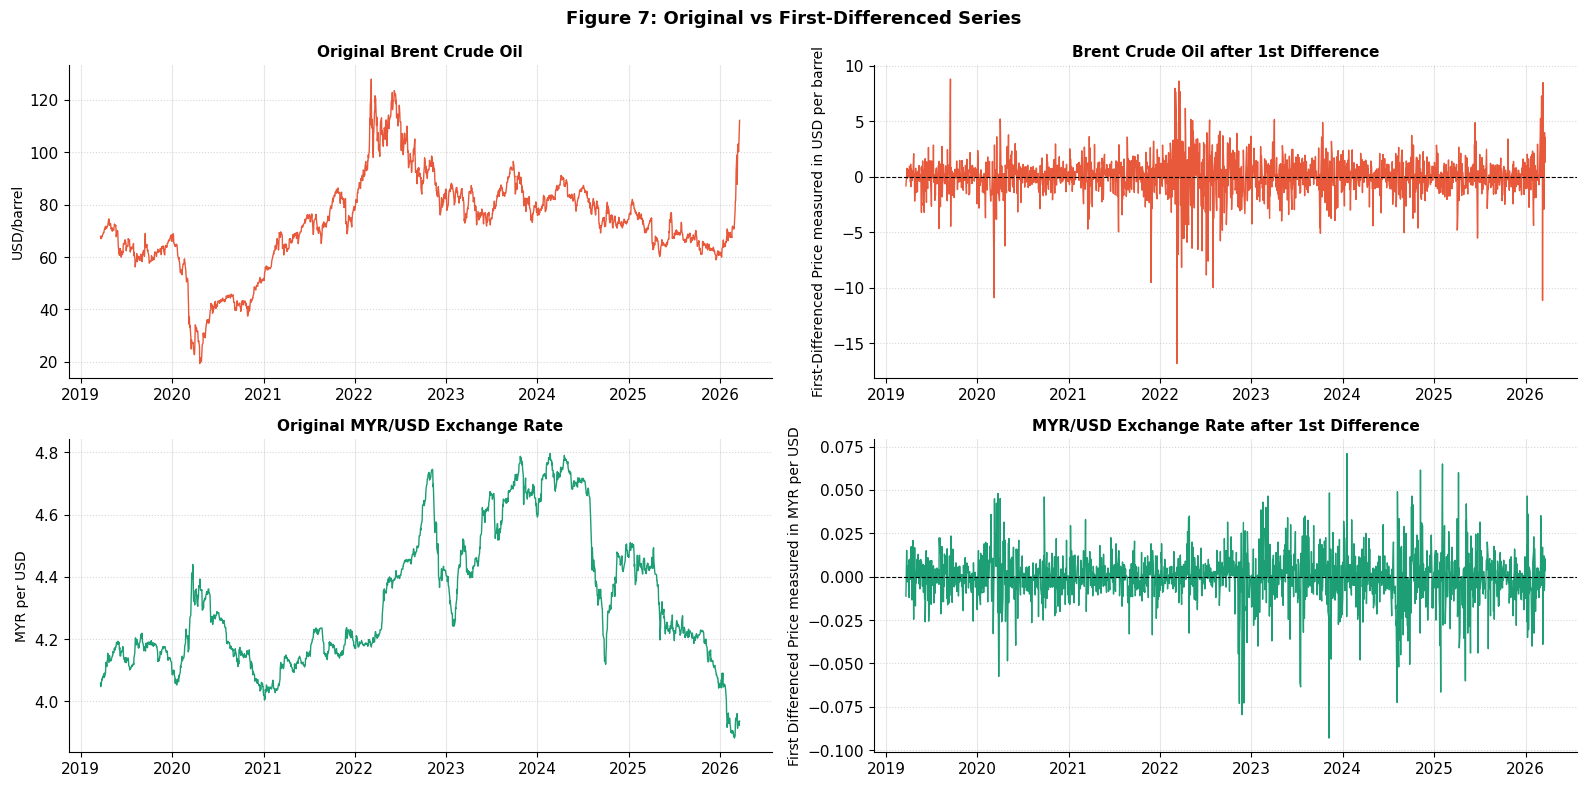

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Figure 7: Original vs First-Differenced Series',
             fontsize=13, fontweight='bold')
axes[0, 0].plot(brent_df['Brent_USD'], color=selected_colors['brent'], linewidth=1.0)
axes[0, 0].set_title('Original Brent Crude Oil', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('USD/barrel', fontsize=10)
axes[0, 0].grid(axis='y', linestyle=':', alpha=0.5)
axes[0, 0].spines[['top', 'right']].set_visible(False)

axes[0, 1].plot(brent_diff, color=selected_colors['brent'], linewidth=1.0)
axes[0, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 1].set_title('Brent Crude Oil after 1st Difference', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('First-Differenced Price measured in USD per barrel', fontsize=10)
axes[0, 1].grid(axis='y', linestyle=':', alpha=0.5)
axes[0, 1].spines[['top', 'right']].set_visible(False)

axes[1, 0].plot(myr_df['USDMYR'], color=selected_colors['myr'], linewidth=1.0)
axes[1, 0].set_title('Original MYR/USD Exchange Rate', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('MYR per USD', fontsize=10)
axes[1, 0].grid(axis='y', linestyle=':', alpha=0.5)
axes[1, 0].spines[['top', 'right']].set_visible(False)

axes[1, 1].plot(myr_diff, color=selected_colors['myr'], linewidth=1.0)
axes[1, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].set_title('MYR/USD Exchange Rate after 1st Difference', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('First Differenced Price measured in MYR per USD', fontsize=10)
axes[1, 1].grid(axis='y', linestyle=':', alpha=0.5)
axes[1, 1].spines[['top', 'right']].set_visible(False)

for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  
plt.tight_layout()
plt.savefig('C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\fig_05_differenced_series.png', dpi=150, bbox_inches='tight')
plt.show()  


#### **3.2  Modelling and Model Selections**   

#### **3.2.a ACF & PACF Analysis**    

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are computed on the first-differenced series to guide the selection of the AR order (`p`) and MA order (`q`) for the ARIMA model. Both plots display 40 lags with 95% confidence bands based on the shaded blue region and if there are any spike exceeding the confidence band is consider as statistically significant. 

**Figure of ACF and PACF of Brent Crude Oil after 1st Difference**

Both the ACF and PACF plots show that after lag 0 all subsequent lags fall within the 95% confidence bands with no clear significant spikes. The ACF drops immediately to near zero after lag 1 and the PACF similarly shows no significant partial
autocorrelations beyond lag 1. This pattern where both ACF and PACF cut off sharply
after lag 0 is a characteristic process of a white noise on the differenced series 
suggesting that a simple ARIMA(0,1,0) or low order ARIMA(p,1,q) with small `p` and `q`
values would be appropriate. The `auto_arima` grid search will confirm the optimal
combination.   

**Figure of ACF and PACF of MYR/USD Exchange Rate after 1st Difference**

The ACF and PACF plots for the differenced MYR/USD series show a very similar pattern 
all lags beyond lag 0 fall within or very close to the 95% confidence bands with no
dominant spikes at any particular lag. A very marginal positive autocorrelation is visible at lag 1 in both plots but it does not extend beyond the confidence threshold
significantly. This again suggests that the differenced series is close to white noise with a low-order ARIMA model expected to be sufficient.

**Summary for Model Selection**

| Series | ACF Pattern | PACF Pattern |  Order |
|--------|-------------|--------------|-----------------|
| Brent Crude Oil | Cuts off after lag 0 | Cuts off after lag 0 | ARIMA(p<=2, 1, q<=2) |
| MYR/USD Rate | Cuts off after lag 0 | Cuts off after lag 0 | ARIMA(p<=2, 1, q<=2) |


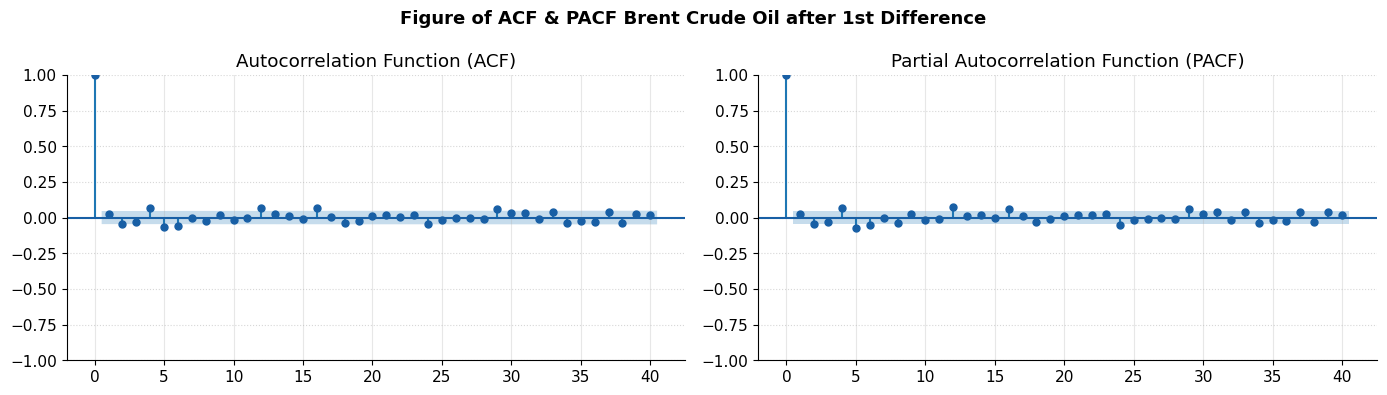

C:\Users\user\OneDrive - Dundalk Institute of Technology\Desktop\Dkit\Dkit 2025\Time Series Analysis\CA2_PeiWenTan_D00253240_TSA\plots_figure_results\fig_06a_acf_pacf_brent.png saved.


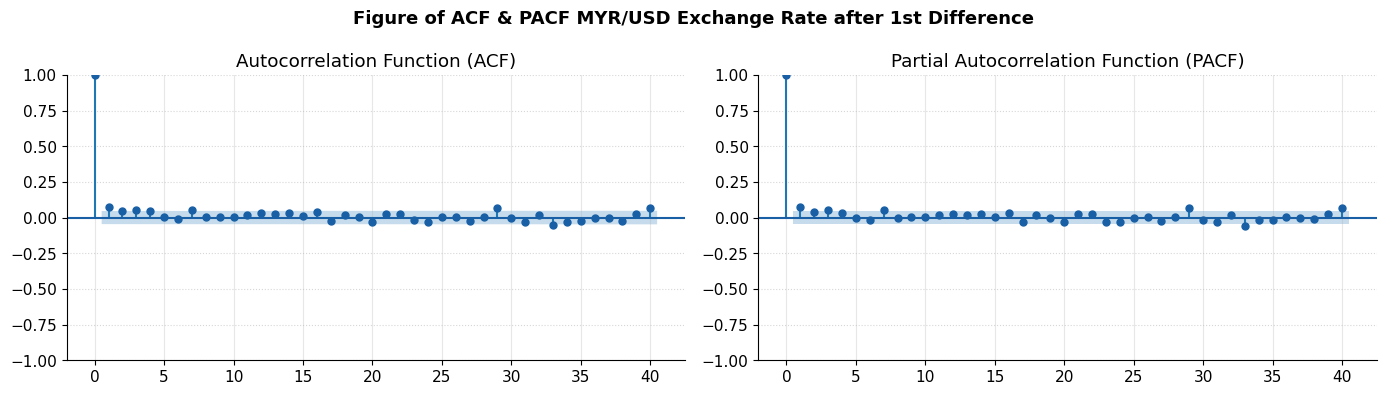

C:\Users\user\OneDrive - Dundalk Institute of Technology\Desktop\Dkit\Dkit 2025\Time Series Analysis\CA2_PeiWenTan_D00253240_TSA\plots_figure_results\fig_06b_acf_pacf_myr.png saved.


In [30]:
def plot_acf_pacf(series, label, figname, lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Figure of ACF & PACF {label}',
                 fontsize=13, fontweight='bold')

    plot_acf(series.dropna(),  ax=axes[0], lags=lags, alpha=0.05,
             color='#185FA5', title='Autocorrelation Function (ACF)')
    plot_pacf(series.dropna(), ax=axes[1], lags=lags, alpha=0.05,
             color='#185FA5', title='Partial Autocorrelation Function (PACF)')

    for ax in axes:
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png saved.')

plot_acf_pacf(brent_diff, 'Brent Crude Oil after 1st Difference',
              figname='fig_06a_acf_pacf_brent')
plot_acf_pacf(myr_diff,   'MYR/USD Exchange Rate after 1st Difference',
              figname='fig_06b_acf_pacf_myr')

#### **3.2.b Auto ARIMA using AIC Grid Search**

`auto_arima` performs a stepwise search over candidate `(p, d, q)` combinations with
`d=1` fixed based on the stationarity results in part 3.1. The best model is selected by minimising the Akaike Information Criterion (AIC).

**Brent Crude Oil**   

The stepwise search evaluated 5 candidate models. The best model selected is
**ARIMA(0,1,0)** with no intercept giving the lowest AIC of **7297.12** and BIC of
**7302.63**. The ARIMA(0,1,0) model  also known as a random walk which implies that the best prediction of tomorrow's Brent price is simply today's price with no autoregressive or moving average terms providing additional explanatory power. This is consistent with the near white noise ACF and PACF patterns observed in part 3.2.a. The model diagnostics show that  
 
- **Ljung-Box Q test at Lag 1 (L1):**    
1. Null Hypothesis: There is no autocorrelation at lag 1 meaning that the data are independently distributed or residuals are white noise.   
2. Alternative Hypothesis: There is autocorrelation at lag 1 where the residuals are not independent.    

Based on the result the p-value = 0.24 which fail to reject the null hypothesis of no autocorrelation in residuals therefore the residuals are uncorrelated.  

- **Jarque-Bera:** p-value = 0.00, indicating the residuals are non-normal which ikely due to the tails caused by the COVID-19 pandemic and other geopolitical shocks
- **Kurtosis of 12.46** confirms heavy-tailed residuals which is consistent with extreme price events in the data


**MYR/USD Exchange Rate**

The stepwise search evaluated 17 candidate models. The best model selected is
**ARIMA(4,1,0)** with no intercept giving the lowest AIC of **−10330.35** and BIC of
**−10,302.80**. The four autoregressive terms (AR(1) to AR(4)) indicate that the current day's exchange rate change is weakly but significantly influenced by the changes over the preceding four business days. All AR coefficients are statistically significant at the 5% level except AR(4) has p = 0.058  which is borderline. The model diagnostics show:

- **Ljung-Box Q (L1):** p-value = 1.00 which fail to reject the null hypothesis of no autocorrelation in residual therefore confirming no residual autocorrelation remains 
- **Jarque-Bera:** p-value = 0.00, indicating non-normal residuals
- **Kurtosis of 8.06** reflects heavier tails than a normal distribution which is  consistent with occasional movement of large exchange rate.   
- **Heteroskedasticity (H):** A p-value of 0.00 indicates that the variance is not constant over time highlighting a well-known limitation of ARIMA models when applied to financial data.     

**Interpretation of coefficient for MYR/USD Exchange rate**

1. **AR(L1) = 0.0668 (p = 0.000)**: A 1 unit increase in yesterday's exchange rate change leads to a 0.0668 unit increase in today's change. Statistically significant at 1% which is the the strongest and most reliable predictor among the four lags.
2. **AR(L2) = 0.0331 (p = 0.035):** A 1 unit increase in the change 2 days ago leads to a 0.0331 unit increase today. Statistically significant at 5%, but the effect is weaker than lag 1.
3. **AR(L3) = 0.0476 (p = 0.005)**: A 1 unit increase in the change 3 days ago leads to a 0.0476 unit increase today. Statistically significant at 1% which is slightly stronger than lag 2.   
4. **AR(L4) = 0.0351 (p = 0.058)**:  A 1 unit increase in the change 4 days ago leads to a 0.0351 unit increase today. Borderline insignificant at the 5% level where the confidence interval [−0.001, 0.071] crosses zero meaning this lag may not reliably contribute to the model.  

**sigma2 = 0.0002 (p = 0.000)**: The estimated variance of the residuals is very small, confirming that daily MYR/USD changes are on average tiny in magnitude.

**Summary**

| Series | Best ARIMA Model | AIC | BIC |
|--------|-----------------|-----|-----|
| Brent Crude Oil | ARIMA(0,1,0) | 7,297.12 | 7,302.63 |
| MYR/USD Rate | ARIMA(4,1,0) | −10,330.35 | −10,302.80 |

The contrast between the two series is clear the Brent Crude behaves like a pure random walk whereas MYR/USD exhibits weak short-term autocorrelation up to four lags  indicating mild mean-reversion in daily exchange rate changes.     


In [31]:
print('Auto ARIMA  of Brent Crude Oil')
arima_brent = auto_arima(
    brent_df['Brent_USD'],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(f'\n Best ARIMA Model : ARIMA{arima_brent.order}')
print(f'AIC: {arima_brent.aic():.4f}')
print(f'BIC: {arima_brent.bic():.4f}')
print(arima_brent.summary())

print('\n Auto ARIMA using the MYR/USD Exchange Rate')
arima_myr = auto_arima(
    myr_df['USDMYR'],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(f'\n Best ARIMA Model : ARIMA{arima_myr.order}')
print(f'AIC: {arima_myr.aic():.4f}')
print(f'BIC: {arima_myr.bic():.4f}')
print(arima_myr.summary())

Auto ARIMA  of Brent Crude Oil
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7298.782, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7299.372, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7299.241, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7297.120, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7300.605, Time=0.23 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.481 seconds

 Best ARIMA Model : ARIMA(0, 1, 0)
AIC: 7297.1199
BIC: 7302.6298
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1827
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3647.560
Date:                Wed, 22 Apr 2026   AIC                           7297.120
Time:                        15:21:36   BIC                           7302.630
Sample:                    03-21-2019   HQIC              

#### **3.2.c ARIMA Model Selection: Comparison of Box-Jenkins with the Selected p and q value vs Auto ARIMA**

Two approaches are applied to identify the optimal ARIMA order for each series,
following the Box-Jenkins methodology outlined in previous sections  

**Step 1: ACF and PACF Suggested Orders follow the Box-Jenkins Identification**

Based on the ACF and PACF plots in subsection 3.2.a both series show all lags falling
within the 95% confidence bands after lag 0, suggesting near white-noise behaviour
on the first-differenced series. Following the Box-Jenkins identification rules, this
pattern implies low-order AR and MA terms which constraining the search space to
`p <= 2, d=1, q<=2` for both series.

**Step 2: Comparisonn of AIC and BIC**

Both approaches are fitted and compared by AIC and BIC:

| Series | Approach | Selected Model | AIC | BIC |
|--------|----------|---------------|-----|-----|
| Brent Crude Oil | Box-Jenkins (p<=2, q<=2) | ARIMA(0,1,0) | 7297.12 | 7302.63 |
| Brent Crude Oil | Auto ARIMA (max_p=5) | ARIMA(0,1,0) | 7297.12 | 7302.63 |
| MYR/USD Rate | Box-Jenkins (p<=2, q<=2) | ARIMA(1,1,1) | −10333.23 | −10316.70 |
| MYR/USD Rate | Auto ARIMA (max_p=5) | ARIMA(4,1,0) | −10330.35 | −10302.80 |

For **Brent Crude Oil** both approaches agree unanimously on **ARIMA(0,1,0)** with identical AIC of 7297.12 confirming that Brent prices follow a pure random
walk with no exploitable autocorrelation structure which isconsistent with the ACF/PACF patterns in subection 3.2.a

For **MYR/USD Exchange Rate** the two approaches diverge:

- **Box-Jenkins (p<=2, q<=2)** selects **ARIMA(1,1,1)** with AIC of −10333.23 combining one AR term and one MA term which capture both the short-term momentum (AR) and the correction of past forecast errors (MA)
- **Auto ARIMA (max_p=5)** selects **ARIMA(4,1,0)** with AIC of −10330.35,
  using four AR lags but no MA terms with a higher-order pure AR model that requires
  more parameters to achieve a slightly worse AIC

**Step 3: Final Model Selection**

The model with the lower AIC is selected as the final model for each series:

| Series | Selected Method | Final Model | AIC | BIC |
|--------|----------------|-------------|-----|-----|
| Brent Crude Oil | Auto ARIMA where both method agree | **ARIMA(0,1,0)** | 7297.12 | 7302.63 |
| MYR/USD Rate | Box-Jenkins | **ARIMA(1,1,1)** | −10333.23 | −10316.70 |  

Both selected models are carried forward to Section SARIMA and Step 5 Forecasting.

In [32]:
print('AUTOARIMA for Brent Crude Oil')
arima_brent_auto = auto_arima(
    brent_df['Brent_USD'],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)

print('\n AUTOARIMA for MYR/USD Exchange Rate')
arima_myr_auto = auto_arima(
    myr_df['USDMYR'],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)


print('\n The BOX-JENKINS selected ARIMA (p<=2, q<=2) for Brent Crude Oil')
print('Justification: ACF and PACF both cut off after lag 0 to p<=2, q<=2')
arima_brent_con = auto_arima(
    brent_df['Brent_USD'],
    d=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    seasonal=False,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)

print('\n The BOX-JENKINS selected ARIMA (p<=2, q<=2) for MYR/USD Exchange Rate')
print('Justification: ACF and PACF both cut off after lag 0 to p<=2, q<=2')
arima_myr_con = auto_arima(
    myr_df['USDMYR'],
    d=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    seasonal=False,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)

print('\n')
print(f'{"Comparison of Box-Jenkins vs Auto ARIMA Model Selection":}')

print('\nStep 1: ACF/PACF Suggested Orders using the order Box-Jenkins Identification:')
print(f'{"Series":<25} {"ACF Pattern":<25} {"PACF Pattern":<20} {"Suggested Order"}')
print(f'{"Brent Crude Oil":<25} {"Cuts off after lag 0":<25} {"Cuts off after lag 0":<20} ARIMA(p<=2, 1, q<=2)')
print(f'{"MYR/USD Rate":<25} {"Cuts off after lag 0":<25} {"Cuts off after lag 0":<20} ARIMA(p<=2, 1, q<=2)')

print('\nStep 2: AIC/BIC Comparison using Box-Jenkins with Selected p and q values vs Auto ARIMA:')
print(f'{"Series":<22} {"Approach":<30} {"Selected Model":<18} {"AIC":>10} {"BIC":>10}')


rows = [
    ('Brent Crude Oil', 'Box-Jenkins (p<=2, q<=2)',  arima_brent_con),
    ('Brent Crude Oil', 'Auto ARIMA (max_p=5)',     arima_brent_auto),
    ('MYR/USD Rate',    'Box-Jenkins (p<=2, q<=2)',  arima_myr_con),
    ('MYR/USD Rate',    'Auto ARIMA (max_p=5)',     arima_myr_auto),
]

for series, approach, model in rows:
    print(f'{series:<22} {approach:<30} '
          f'{"ARIMA"+str(model.order):<18} '
          f'{model.aic():>10.2f} {model.bic():>10.2f}')

print('\nStep 3: Final Model Selection with the lower AIC, the better:')


brent_winner = arima_brent_auto if arima_brent_auto.aic() <= arima_brent_con.aic() \
               else arima_brent_con
brent_method = 'Auto ARIMA' if arima_brent_auto.aic() <= arima_brent_con.aic() \
               else 'Box-Jenkins'
print(f'Brent Crude Oil: {brent_method} | '
      f'ARIMA{brent_winner.order} | '
      f'AIC={brent_winner.aic():.2f} | '
      f'BIC={brent_winner.bic():.2f}')

myr_winner = arima_myr_auto if arima_myr_auto.aic() <= arima_myr_con.aic() \
             else arima_myr_con
myr_method = 'Auto ARIMA' if arima_myr_auto.aic() <= arima_myr_con.aic() \
             else 'Box-Jenkins'
print(f'MYR/USD Rate: {myr_method} | '
      f'ARIMA{myr_winner.order} | '
      f'AIC={myr_winner.aic():.2f} | '
      f'BIC={myr_winner.bic():.2f}')   
print('Note: Selected models will be used for SARIMA extension and forecasting.')  

arima_brent_final = brent_winner
arima_myr_final   = myr_winner

AUTOARIMA for Brent Crude Oil
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7298.782, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7299.372, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7299.241, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7297.120, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7300.605, Time=0.23 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.497 seconds

 AUTOARIMA for MYR/USD Exchange Rate
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-10317.250, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-10324.972, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-10324.300, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-10319.210, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-10325.601, Time=0.15 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-10328.132, Time=0.17 sec
 ARIMA(4,1,0)(0,0,0)[0] interce

#### **3.2.d SARIMA Model Selection: Comparison of Box-Jenkins with the Selected p and q value vs Auto SARIMA**  

Two approaches are applied to identify the optimal SARIMA order for each series extending the Box-Jenkins methodology from previous section to include seasonal components `(P, D, Q)[m]` with `m=5` reflecting the weekly business day cycle.

**Step 1: Non-Seasonal Constraints which is carried forward from Section 3.2.c**

The non-seasonal orders `(p, q)` for the constrained SARIMA are inherited directly from the final ARIMA selections in Section 3.2.c:

| Series | Selected ARIMA | SARIMA Non-Seasonal Constraint |
|--------|---------------|-------------------------------|
| Brent Crude Oil | ARIMA(0,1,0) | p<=0, q<=0, D=1, P<=2, Q<=2, m=5 |
| MYR/USD Rate | ARIMA(1,1,1) | p<=1, q<=1, D=1, P<=2, Q<=2, m=5 |

**Step 2: Comparison of AIC and BIC**

| Series | Approach | Selected Model | AIC | BIC |
|--------|----------|---------------|-----|-----|
| Brent Crude Oil | Box-Jenkins (Constrained) | SARIMA(0,1,0)(2,1,0)[5] | 7820.86 | 7837.38 |
| Brent Crude Oil | Auto SARIMA (Unconstrained) | SARIMA(0,1,0)(2,1,0)[5] | 7820.86 | 7837.38 |
| MYR/USD Rate | Box-Jenkins (Constrained) | SARIMA(1,1,0)(2,1,0)[5] | −9778.52 | −9756.49 |
| MYR/USD Rate | Auto SARIMA (Unconstrained) | SARIMA(1,1,0)(2,1,0)[5] | −9778.52 | −9756.49 |

Unlike the ARIMA comparison in Section 3.2.c where the two approaches diverged for
MYR/USD both Box-Jenkins and Auto SARIMA **agree** on the same model for both series  yielding identical AIC and BIC values. This is a strong validation of the selected seasonal structure.

For **Brent Crude Oil** both approaches select **SARIMA(0,1,0)(2,1,0)[5]** with
AIC of 7820.86. The model contains no non-seasonal AR or MA terms which is  consistent with the random walk behaviour confirmed in previous section but includes two seasonal AR terms at lags 5 and 10, capturing a weekly mean-reverting pattern in Brent prices.

For **MYR/USD Exchange Rate**, both approaches select **SARIMA(1,1,0)(2,1,0)[5]**
with AIC of −9,778.52. The non-seasonal AR(1) term carries forward from the
ARIMA(1,1,1) selection, while the two seasonal AR terms at lags 5 and 10 capture
the same weekly cycle is identified in the Brent series. Notably the MA(1) term from
ARIMA(1,1,1) is dropped in the SARIMA framework suggesting that once the seasonal
structure is accounted for the moving average component no longer provides
additional explanatory power.   

**Step 3: Final SARIMA Selection**

| Series | Selected Method | Final Model | AIC | BIC |
|--------|----------------|-------------|-----|-----|
| Brent Crude Oil | Both agree | **SARIMA(0,1,0)(2,1,0)[5]** | 7820.86 | 7837.38 |
| MYR/USD Rate | Both agree | **SARIMA(1,1,0)(2,1,0)[5]** | −9778.52 | −9756.49 |

The agreement between Box-Jenkins and Auto SARIMA for both series strongly validates the seasonal model selection. Both series share the same seasonal structure `(2,1,0)[5]` indicating that a 2 week business-day seasonal AR pattern with weekly differencing is the most informative seasonal component for both Brent Crude Oil and MYR/USD at daily frequency. Both selected SARIMA models are carried forward to Step 4 Diagnostics alongside the selected ARIMA models.

In [33]:
print('AUTO SARIMA for Brent Crude Oil')
sarima_brent_auto = auto_arima(
    brent_df['Brent_USD'],
    d=1, D=1,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    seasonal=True,
    m=5,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)
print(f'\nBest Auto SARIMA : SARIMA{sarima_brent_auto.order}x{sarima_brent_auto.seasonal_order}')
print(f'AIC: {sarima_brent_auto.aic():.4f} ; BIC: {sarima_brent_auto.bic():.4f}')
print(sarima_brent_auto.summary())

print('\n AUTO SARIMA for MYR/USD Exchange Rate')
sarima_myr_auto = auto_arima(
    myr_df['USDMYR'],
    d=1, D=1,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    seasonal=True,
    m=5,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)
print(f'\n Best Auto SARIMA : SARIMA{sarima_myr_auto.order}x{sarima_myr_auto.seasonal_order}')
print(f'AIC: {sarima_myr_auto.aic():.4f} ; BIC: {sarima_myr_auto.bic():.4f}')
print(sarima_myr_auto.summary())


print('\n BOX-JENKINS Selected SARIMA for Brent Crude Oil ===')
print('Constraint: p<=0, q<=0 from ARIMA(0,1,0) selection with P<=2, Q<=2, m=5')
sarima_brent_con = auto_arima(
    brent_df['Brent_USD'],
    d=1, D=1,
    start_p=0, max_p=0,   #selected from ARIMA(0,1,0)
    start_q=0, max_q=0,   #selected from ARIMA(0,1,0)
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    seasonal=True,
    m=5,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)
print(f'\nBest Box-Jenkins SARIMA : SARIMA{sarima_brent_con.order}x{sarima_brent_con.seasonal_order}')
print(f'AIC: {sarima_brent_con.aic():.4f} | BIC: {sarima_brent_con.bic():.4f}')
print(sarima_brent_con.summary())

print('\n BOX-JENKINS Selected SARIMA for MYR/USD Exchange Rate')
print('Constraint: p<=1, q<=1 from ARIMA(1,1,1) selection with P<=2, Q<=2, m=5')
sarima_myr_con = auto_arima(
    myr_df['USDMYR'],
    d=1, D=1,
    start_p=0, max_p=1,   #selected from ARIMA(1,1,1)
    start_q=0, max_q=1,   #selected from ARIMA(1,1,1)
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    seasonal=True,
    m=5,
    information_criterion='aic',
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True
)
print(f'\nBest Box-Jenkins SARIMA : SARIMA{sarima_myr_con.order}x{sarima_myr_con.seasonal_order}')
print(f'AIC: {sarima_myr_con.aic():.4f} ; BIC: {sarima_myr_con.bic():.4f}')
print(sarima_myr_con.summary())

print('\n')
print(f'{"Comparison of Box-Jenkins vs Auto SARIMA Model Selection":^85}')

print('\n Step 1: Non-Seasonal Orders from Section 3.2.c:')
print(f'{"Series":<25} {"Selected ARIMA":<20} {"Constraint for SARIMA"}')
print(f'{"Brent Crude Oil":<25} {"ARIMA(0,1,0)":<20} p≤0, q≤0, D=1, P≤2, Q≤2, m=5')
print(f'{"MYR/USD Rate":<25} {"ARIMA(1,1,1)":<20} p≤1, q≤1, D=1, P≤2, Q≤2, m=5')

print('\nStep 2: AIC/BIC Comparison with Box-Jenkins Selected p and q vs Auto SARIMA:')
print(f'{"Series":<22} {"Approach":<32} {"Selected Model":<28} {"AIC":>8} {"BIC":>8}')  

rows = [
    ('Brent Crude Oil', 'Box-Jenkins (Constrained)',
     f'SARIMA{sarima_brent_con.order}x{sarima_brent_con.seasonal_order}',
     sarima_brent_con.aic(), sarima_brent_con.bic()),
    ('Brent Crude Oil', 'Auto SARIMA (Unconstrained)',
     f'SARIMA{sarima_brent_auto.order}x{sarima_brent_auto.seasonal_order}',
     sarima_brent_auto.aic(), sarima_brent_auto.bic()),
    ('MYR/USD Rate',    'Box-Jenkins (Constrained)',
     f'SARIMA{sarima_myr_con.order}x{sarima_myr_con.seasonal_order}',
     sarima_myr_con.aic(), sarima_myr_con.bic()),
    ('MYR/USD Rate',    'Auto SARIMA (Unconstrained)',
     f'SARIMA{sarima_myr_auto.order}x{sarima_myr_auto.seasonal_order}',
     sarima_myr_auto.aic(), sarima_myr_auto.bic()),
]

for series, approach, model_str, aic, bic in rows:
    print(f'{series:<22} {approach:<32} {model_str:<28} {aic:>8.2f} {bic:>8.2f}')

print('\n Step 3: Final SARIMA Selection the lower AIC the better the model:')


if sarima_brent_auto.aic() <= sarima_brent_con.aic():
    brent_sarima_final  = sarima_brent_auto
    brent_sarima_method = 'Auto SARIMA'
else:
    brent_sarima_final  = sarima_brent_con
    brent_sarima_method = 'Box-Jenkins'

print(f'Selected Model for Brent Crude Oil: {brent_sarima_method} | '
      f'SARIMA{brent_sarima_final.order}x{brent_sarima_final.seasonal_order} | '
      f'AIC={brent_sarima_final.aic():.2f} | BIC={brent_sarima_final.bic():.2f}')

if sarima_myr_auto.aic() <= sarima_myr_con.aic():
    myr_sarima_final  = sarima_myr_auto
    myr_sarima_method = 'Auto SARIMA'
else:
    myr_sarima_final  = sarima_myr_con
    myr_sarima_method = 'Box-Jenkins'
print(f'Selected Model for MYR/USD Exchange Rate: {myr_sarima_method} | '
      f'SARIMA{myr_sarima_final.order}x{myr_sarima_final.seasonal_order} | '
      f'AIC={myr_sarima_final.aic():.2f} | BIC={myr_sarima_final.bic():.2f}')

print('Note: Selected SARIMA models will be carried forward to Step 4 Diagnostics.')
sarima_brent_final = brent_sarima_final
sarima_myr_final   = myr_sarima_final

AUTO SARIMA for Brent Crude Oil
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=8650.345, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=8063.759, Time=0.12 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=inf, Time=0.63 sec
 ARIMA(1,1,0)(0,1,0)[5]             : AIC=8651.582, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[5]             : AIC=7822.854, Time=0.21 sec
 ARIMA(1,1,0)(2,1,1)[5]             : AIC=inf, Time=1.73 sec
 ARIMA(1,1,0)(1,1,1)[5]             : AIC=inf, Time=1.15 sec
 ARIMA(0,1,0)(2,1,0)[5]             : AIC=7820.859, Time=0.14 sec
 ARIMA(0,1,0)(1,1,0)[5]             : AIC=8062.570, Time=0.08 sec
 ARIMA(0,1,0)(2,1,1)[5]             : AIC=inf, Time=0.91 sec
 ARIMA(0,1,0)(1,1,1)[5]             : AIC=inf, Time=0.49 sec
 ARIMA(0,1,1)(2,1,0)[5]             : AIC=7822.853, Time=0.19 sec
 ARIMA(1,1,1)(2,1,0)[5]             : AIC=7824.683, Time=0.65 sec
 ARIMA(0,1,0)(2,1,0)[5] intercept   : AIC=7822.795, Time=0.34 sec

Best model:  ARIMA(0,1,0)

### **Step 4: Diagnostics**

#### **4.1 Model Comparison based on AIC and BIC**

The AIC and BIC of the final selected ARIMA and SARIMA models are compared
for each series. A lower AIC/BIC indicates a better trade-off between model fit and
complexity.    

| Series | Model | AIC | BIC |
|--------|-------|-----|-----|
| Brent Crude Oil | ARIMA(0,1,0) | 7297.12 | 7302.63 |
| Brent Crude Oil | SARIMA(0,1,0)(2,1,0)[5] | 7820.86 | 7837.38 |
| MYR/USD Rate | ARIMA(1,1,1) | −10333.23 | −10316.70 |
| MYR/USD Rate | SARIMA(1,1,0)(2,1,0)[5] | −9778.52 | −9756.49 |

For both series, **ARIMA outperforms SARIMA** on both AIC and BIC given that ARIMA(0,1,0) is selected for Brent Crude Oil and ARIMA(1,1,1) is selected for MYR/USD Rate.


#### **4.2 Interpretation of Summaries of Final Selected Model**

**Brent Crude Oil with ARIMA(0,1,0)**

The model contains only one estimated parameter which is the the residual variance sigma2:

| Parameter | Coefficient | p-value | Interpretation |
|-----------|------------|---------|----------------|
| sigma2 | 3.1812 | 0.000 | Residual variance given that sigma2 is approximate 3.18 which is around $1.78 per barrel daily shock |

ARIMA(0,1,0) is a **pure random walk** which mean the best forecast of tomorrow's price is simply today's price plus a random shock of approximately +-$1.78 per barrel. The absenceof AR and MA terms confirms that no past price information improves the forecast beyond the current observation. The diagnostic statistics show that 
- **Ljung-Box Q test at Lag 1 (L1):**    
1. Null Hypothesis: There is no autocorrelation at lag 1 meaning that the data are independently distributed or residuals are white noise.   
2. Alternative Hypothesis: There is autocorrelation at lag 1 where the residuals are not independent. 

Based on the observed p-value = 0.24of Ljung-Box Q test itfails to reject the null hypothesis conclude that there is no autocorrelation confirming that residuals are white noise 
- **Jarque-Bera: p-value = 0.00** meaning that residuals are non-normal possibly driven by the extreme COVID-19 and geopolitical war price shocks retained in the data
- **Kurtosis = 12.46** which mean there is a heavy-tailed residuals that is consistent with the geopolitical outlier events
- **Heteroskedasticity H: p-value = 0.03** show borderline evidence of non-constant variance reflecting the volatile periods in 2020 and 2022

**MYR/USD Exchange Rate with ARIMA(1,1,1)**

The model contains 3 estimated parameters:

| Parameter | Coefficient | p-value | Interpretation |
|-----------|------------|---------|----------------|
| ar.L1 | 0.7556 | 0.000 | Strong positive AR(1) meaning today's change is significantly influenced by yesterday's change |
| ma.L1 | −0.6870 | 0.000 | The negative MA(1) coefficient indicates that forecast errors from the previous day are partially reversed in the current period. In practical terms, if the model overestimates yesterday it will adjust downward today and vice versa helping to stabilise short-term fluctuations. |
| sigma2 | 0.0002 | 0.000 | Very small residual variance because the sigma is approximate 0.014 MYR per USD daily |

Both AR(1) and MA(1) coefficients are highly significant (p < 0.001) and work in
opposite directions given that the large positive AR(1) with coefficient of 0.7556 captures strong momentum in daily exchange rate changes while the negative MA(1) with coefficient of −0.6870 partially offsetsthis by correcting for the previous error producing a near-cancelling but statistically meaningful dynamic. The diagnostic statistics show:

- **Ljung-Box Q test at Lag 1 (L1):**    
1. Null Hypothesis: There is no autocorrelation at lag 1 meaning that the data are independently distributed or residuals are white noise.   
2. Alternative Hypothesis: There is autocorrelation at lag 1 where the residuals are not independent. 

Based on the  Ljung-Box Q (L1) the p-value = 0.92 meaning we fail to reject the null hypothesis and conclude that there is no residual autocorrelation remains confirming the model has captured all exploitable structure   

- **Jarque-Bera: p-value = 0.00** meaning that it has non-normal residuals
- **Kurtosis = 8.00** indicate heavy-tailed but less extreme than Brent suggesting ARIMA(1,1,1) absorbs more of the variation than the random walk model
- **Heteroskedasticity H: p-value = 0.00** which show significant non-constant variance which is a known limitation of ARIMA on financial exchange rate data


#### **4.3 Residual Diagnostics**

**Brent Crude Oil with ARIMA(0,1,0)**

- **Residuals over time:** Oscillate around zero with no trend but two clusters of elevated volatility are visible around observations 250 possibly due to COVID-19 in 2020 and 750 during the geopolitical war happened in 2022 this indicate heteroskedasticity during shock periods  

- **Residual distribution:** Highly peaked and right-skewed with a long right tail which is consistent with the Kurtosis of 12.46 and has a non-normal residuals driven by the outliers of retained geopolitical  

- **ACF of residuals:** All lags fall within the 95% confidence bands meaning there is no remaining autocorrelation  

- **Q-Q plot:** Most  of the residuals follow the diagonal but extreme deviations at both tails confirm heavy-tailed and non-normal residuals

**Brent Crude Oil with SARIMA(0,1,0)(2,1,0)[5]**

- **Residuals over time:** Similar to ARIMA but the spike at observation at around 750 is more pronounced with approximate −30 suggesting seasonal differencing amplifies the shock
- **Residual distribution:** Slightly more spread with heavier left tail
- **ACF of residuals:** Significant spikes at lags 5 and 10 exceed the confidence bands and seasonal autocorrelation remains in residuals  
- **Q-Q plot:** Heavy tails at both extremes which is similar to ARIMA

**MYR/USD Rate with ARIMA(1,1,1)**

- **Residuals over time:** Extremely small and tightly clustered around zero throughout the full period but has the best residual behaviour of all four models 
- **Residual distribution:** Highly concentrated near zero with very narrow spread and consistent with the small sigma2 of 0.0002
- **ACF of residuals:** All lags fall cleanly within confidence bands with no significant spikes 
- **Q-Q plot:** Majority of points follow the diagonal closely with only one extreme outlier at the upper tail and near-normal residuals 

**MYR/USD Rate with SARIMA(1,1,0)(2,1,0)[5]**

- **Residuals over time:** Residuals remain close to zero throughout
- **Residual distribution:** Almost entirely concentrated at zero with a single narrow bar dominates the histogram
- **ACF of residuals:** A significant spike at lag 5 exceeds the confidence band which mean there is remain of residual seasonal autocorrelation
- **Q-Q plot:** Similar to ARIMA(1,1,1) with one upper tail outlier  

#### **Summary of Diagnostics**

| Series | Model | Is ACF Clean | Normality | Selected |
|--------|-------|-------------|-----------|---------|
| Brent Crude Oil | ARIMA(0,1,0) | Clean | Non-normal with heavy tails | Yes |
| Brent Crude Oil | SARIMA(0,1,0)(2,1,0)[5] | Spikes at lag 5, 10 and 15 | Non-normal with heavy tails | No |
| MYR/USD Rate | ARIMA(1,1,1) | Clean | Near-normal | Yes |
| MYR/USD Rate | SARIMA(1,1,0)(2,1,0)[5] | Spike at lag 5 | Near-normal | No |
 
**Note: Although SARIMA models were not selected based on performance metrics since their AIC values were slightly higher than those of the ARIMA models we are still interested in evaluating how SARIMA performs in forecasting for study purposes.**   

                   Model Comparison of AIC and BIC                    
Series                    Model                               AIC      BIC
Brent Crude Oil           ARIMA(0, 1, 0)                  7297.12  7302.63
Brent Crude Oil           SARIMA(0, 1, 0)x(2, 1, 0, 5)    7820.86  7837.38
MYR/USD Rate              ARIMA(1, 1, 1)                 -10333.23 -10316.70
MYR/USD Rate              SARIMA(1, 1, 0)x(2, 1, 0, 5)   -9778.52 -9756.49

Best Model by AIC:
Brent Crude Oil ARIMA(0, 1, 0) (AIC=7297.12) is Selected
MYR/USD Rate ARIMA(1, 1, 1) (AIC=-10333.23) is Selected


                   Summary of Final Selected Models                   

 1. Brent Crude Oil Selected Model: ARIMA(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1827
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3647.560
Date:                Wed, 22 Apr 2026   AIC              

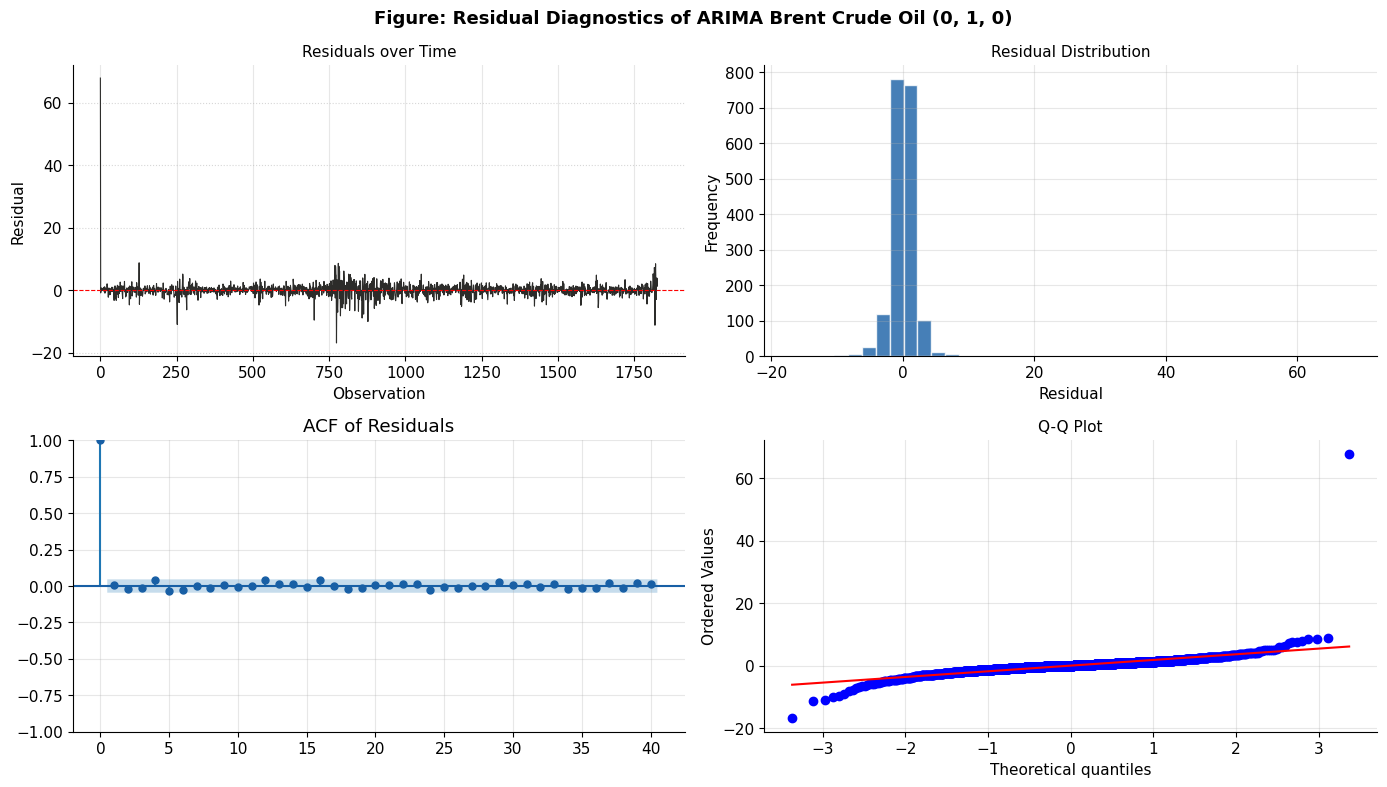

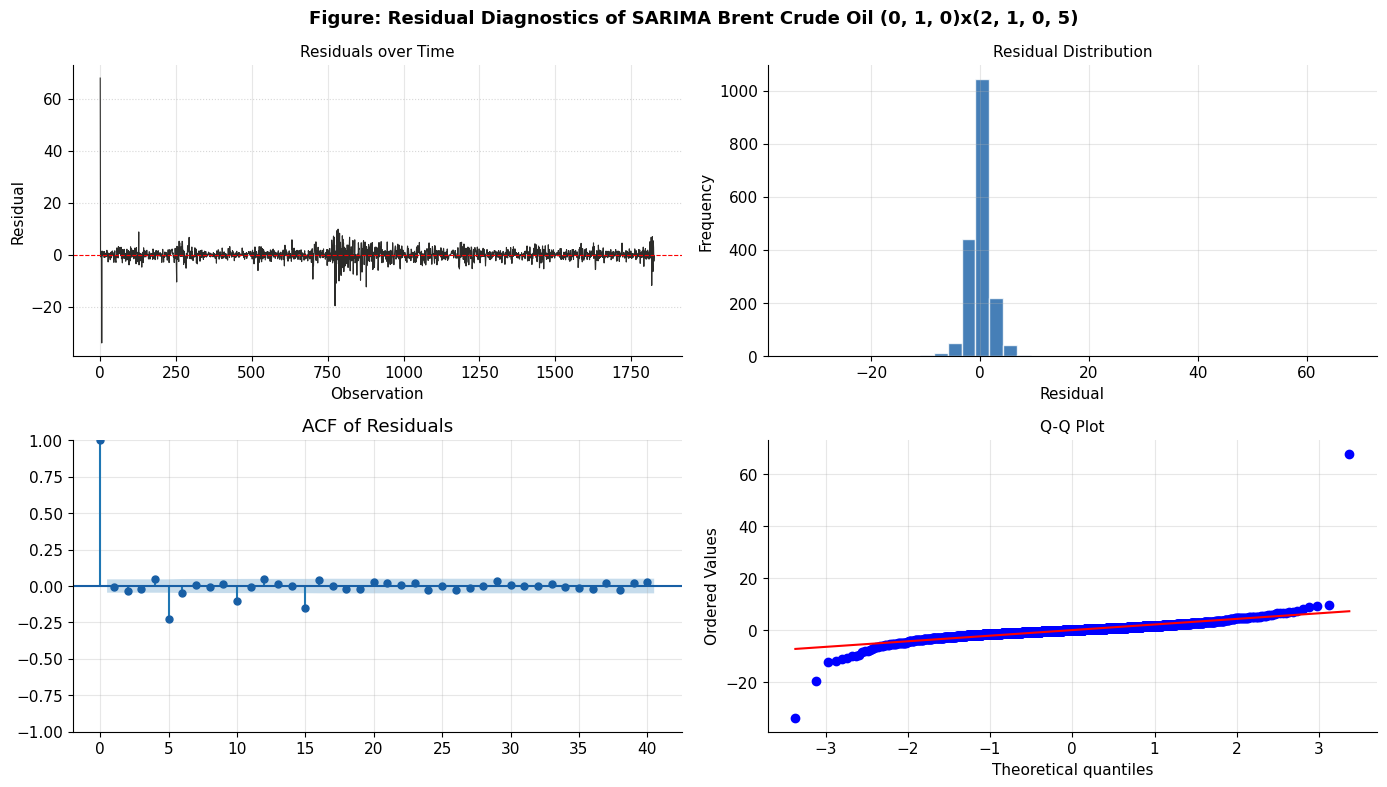

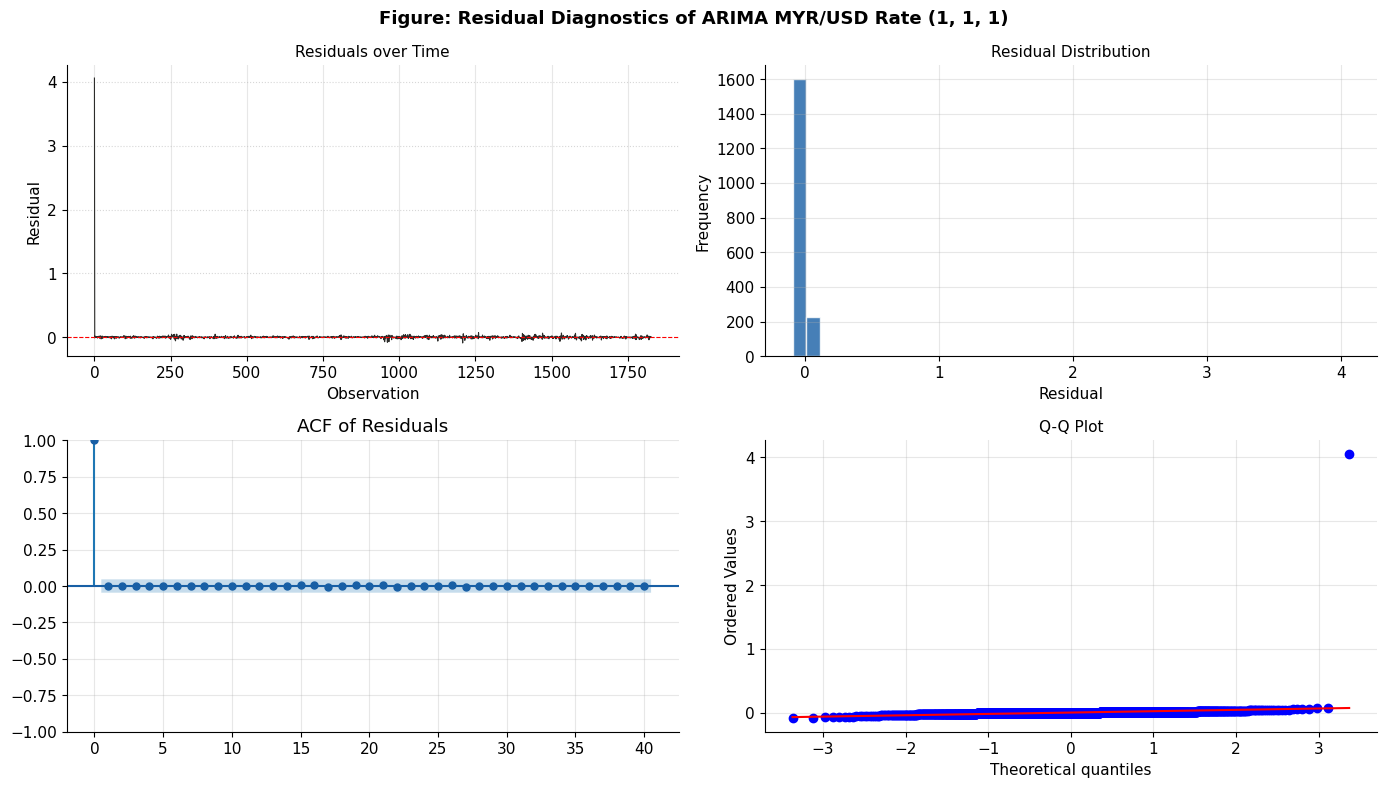

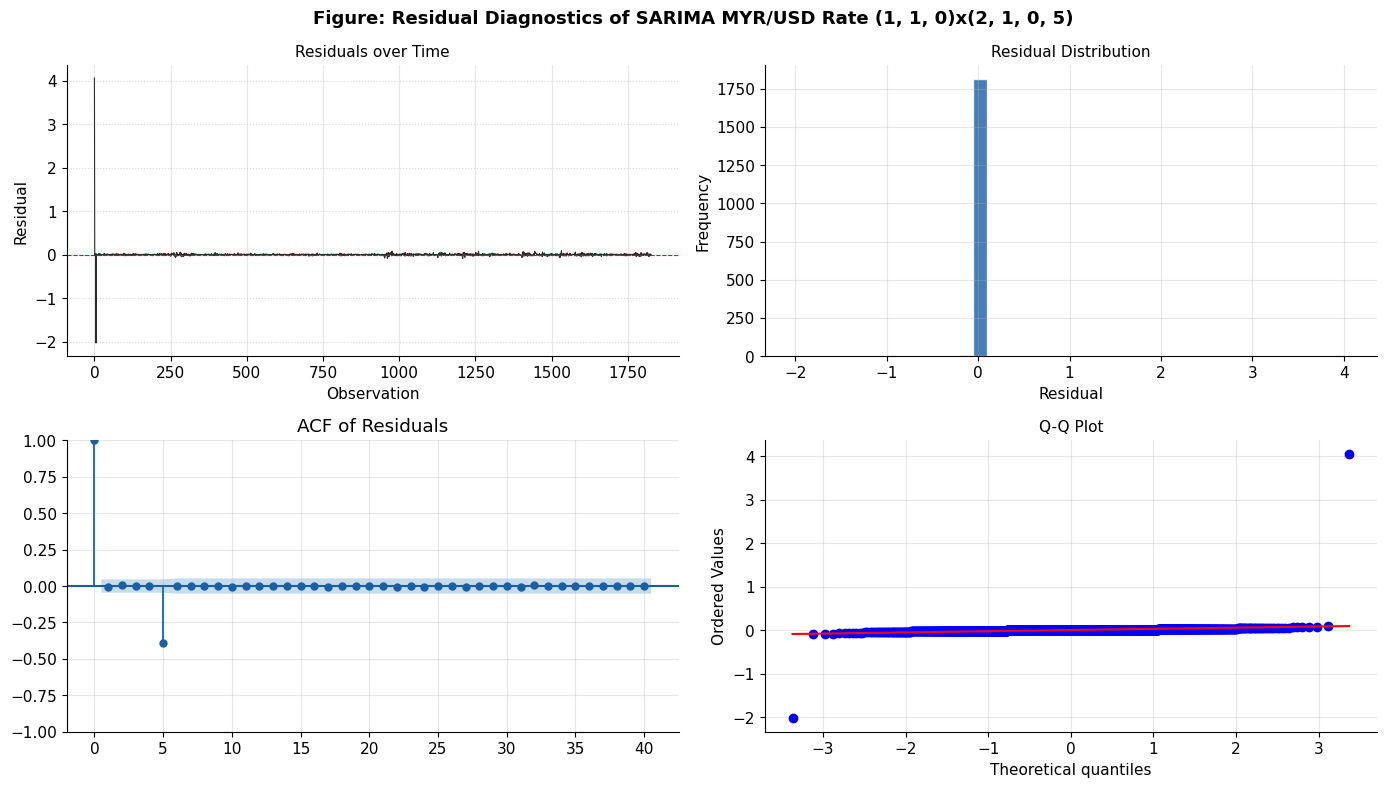

In [34]:
print(f'{"Model Comparison of AIC and BIC":^70}')
print(f'{"Series":<25} {"Model":<30} {"AIC":>8} {"BIC":>8}')
print(f'{"Brent Crude Oil":<25} '
      f'{str(f"ARIMA{arima_brent_final.order}"):<30} '
      f'{arima_brent_final.aic():>8.2f} '
      f'{arima_brent_final.bic():>8.2f}')
print(f'{"Brent Crude Oil":<25} '
      f'{str(f"SARIMA{sarima_brent_final.order}x{sarima_brent_final.seasonal_order}"):<30} '
      f'{sarima_brent_final.aic():>8.2f} '
      f'{sarima_brent_final.bic():>8.2f}')
print(f'{"MYR/USD Rate":<25} '
      f'{str(f"ARIMA{arima_myr_final.order}"):<30} '
      f'{arima_myr_final.aic():>8.2f} '
      f'{arima_myr_final.bic():>8.2f}')
print(f'{"MYR/USD Rate":<25} '
      f'{str(f"SARIMA{sarima_myr_final.order}x{sarima_myr_final.seasonal_order}"):<30} '
      f'{sarima_myr_final.aic():>8.2f} '
      f'{sarima_myr_final.bic():>8.2f}')

print('\nBest Model by AIC:')

if arima_brent_final.aic() <= sarima_brent_final.aic():
    brent_best = arima_brent_final
    brent_best_label = f'ARIMA{arima_brent_final.order}'
    print(f'Brent Crude Oil ARIMA{arima_brent_final.order} '
          f'(AIC={arima_brent_final.aic():.2f}) is Selected')
else:
    brent_best = sarima_brent_final
    brent_best_label = f'SARIMA{sarima_brent_final.order}x{sarima_brent_final.seasonal_order}'
    print(f'Brent Crude Oil SARIMA{sarima_brent_final.order}x'
          f'{sarima_brent_final.seasonal_order} '
          f'(AIC={sarima_brent_final.aic():.2f}) is Selected')

if arima_myr_final.aic() <= sarima_myr_final.aic():
    myr_best = arima_myr_final
    myr_best_label = f'ARIMA{arima_myr_final.order}'
    print(f'MYR/USD Rate ARIMA{arima_myr_final.order} '
          f'(AIC={arima_myr_final.aic():.2f}) is Selected')
else:
    myr_best = sarima_myr_final
    myr_best_label = f'SARIMA{sarima_myr_final.order}x{sarima_myr_final.seasonal_order}'
    print(f'MYR/USD Rate SARIMA{sarima_myr_final.order}x'
          f'{sarima_myr_final.seasonal_order} '
          f'(AIC={sarima_myr_final.aic():.2f}) is Selected')


print('\n')
print(f'{"Summary of Final Selected Models":^70}')
print(f'\n 1. Brent Crude Oil Selected Model: {brent_best_label}')
print(brent_best.summary())
print(f'\n 2. MYR/USD Exchange Rate Selected Model: {myr_best_label}')
print(myr_best.summary())



def plot_diagnostics(model, label, figname):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Figure: Residual Diagnostics of {label}',
                 fontsize=13, fontweight='bold')

    residuals = pd.Series(model.resid())
    
    axes[0, 0].plot(residuals.values, color='#2C2C2A', linewidth=0.8)
    axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0, 0].set_title('Residuals over Time', fontsize=11)
    axes[0, 0].set_xlabel('Observation')
    axes[0, 0].set_ylabel('Residual')
    axes[0, 0].grid(axis='y', linestyle=':', alpha=0.5)
    axes[0, 0].spines[['top', 'right']].set_visible(False)

    axes[0, 1].hist(residuals, bins=40, color='#185FA5',
                    edgecolor='white', alpha=0.8)
    axes[0, 1].set_title('Residual Distribution', fontsize=11)
    axes[0, 1].set_xlabel('Residual')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].spines[['top', 'right']].set_visible(False)

    plot_acf(residuals, ax=axes[1, 0], lags=40, alpha=0.05,
             color='#185FA5', title='ACF of Residuals')
    axes[1, 0].spines[['top', 'right']].set_visible(False)

    stats.probplot(residuals, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot', fontsize=11)
    axes[1, 1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

plot_diagnostics(
    arima_brent_final,
    f'ARIMA Brent Crude Oil {arima_brent_final.order}',
    'fig_07a_diag_arima_brent'
)
plot_diagnostics(
    sarima_brent_final,
    f'SARIMA Brent Crude Oil {sarima_brent_final.order}x{sarima_brent_final.seasonal_order}',
    'fig_07b_diag_sarima_brent'
)
plot_diagnostics(
    arima_myr_final,
    f'ARIMA MYR/USD Rate {arima_myr_final.order}',
    'fig_07c_diag_arima_myr'
)
plot_diagnostics(
    sarima_myr_final,
    f'SARIMA MYR/USD Rate {sarima_myr_final.order}x{sarima_myr_final.seasonal_order}',
    'fig_07d_diag_sarima_myr'
)


### **Step 5: Forecasting**  

#### **5.1 Model 1: ARIMA Forecast**   

The selected ARIMA models from subsection 3.2.c are trained on all available observations except the final 30 business days which are reserved as the out-of-sample test set. This approach maximises the training information while directly evaluating the  30 days forecast horizon.

| | Brent Crude Oil | MYR/USD Rate |
|--|----------------|--------------|
| Model | ARIMA(0,1,0) | ARIMA(1,1,1) |
| Train | 1797 observation from 21 Mar 2019 to 06 Feb 2026 | 1797 observation from 21 Mar 2019 to 06 Feb 2026 |
| Test | 30 observations from 09 Feb 2026 to 20 Mar 2026 | 30 obseravtions from 09 Feb 2026 to 20 Mar 2026 |

##### **Brent Crude Oil with ARIMA(0,1,0)**

The ARIMA(0,1,0) model produces a **flat forecast** at approximately $68 per barrel across the 30 day horizon. This is consistent with the random walk assumption where the best prediction of future values is simply the most recent observed price.    

The **95% confidence interval** widens over time which reflecting increasing forecast uncertainty:
- Day 1: approximately range from $60 to $77  
- Day 30: approximately range $50 to $90 

##### **Forecast vs Actual Performance for Brent Crude Oil with ARIMA(0,1,0)**

During the test period from **09 Feb 2026  to 20 Mar 2026** the actual price diverged sharply with the forecast price rising from around $68 to $112 per barrel with an increase of around 65% within 30 days. 

This surge is directly attributable to a **geopolitical war shock happened in February 2026** **which triggered a rapid escalation in oil prices.** As a result, actual prices move **above the upper bound of the 95% confidence interval** by middle of March. This **structural break** represent **an extreme and exogenous event that lies outside the historical patterns captured by the model.**

##### **Forecast Accuracy Metrics for Brent Crude Oil with ARIMA(0,1,0)**

| Metric | Value |
|--------|-------|
| MAE    | 14.7547 |
| RMSE   | 20.8789 |
| MAPE   | 15.36% |

The **MAPE of 15.36%** confirms that the model significantly underestimates the magnitude of the price increase during this shock period.

##### **Residual Diagnostics for Brent Crude Oil with ARIMA(0,1,0)**

- **Ljung–Box Test (p = 0.01):** Indicates residual autocorrelation suggesting that some structure remains unmodelled.  
- **Kurtosis (23.11):** Extremely high which reflecting heavy tails driven by the geopolitical shock.     

##### **Summary for Brent Crude Oil with ARIMA(0,1,0)**

While ARIMA(0,1,0) is appropriate for modelling a random walk under normal market conditions **it is inherently unable to anticipate sudden geopolitical shocks.** The sharp price surge following the February 2026 war highlights this limitation and  demonstrate that such models are not robust to extreme and exogenous events.


--- 

##### **MYR/USD Exchange Rate with ARIMA(1,1,1)**

The model produces a **near-flat forecast** at approximately 3.95 MYR per USD with the AR(1) coefficient of 0.8437 and MA(1) coefficient of −0.7793 largely cancelling each other out producing minimal drift beyond the first step.**The 95% confidence interval are at the range around  3.75 MYR per USD to 4.15 MYR per USD** by day 30 reflecting modest but growing uncertainty consistent with the small sigma2 of 1.067×10^-5.   

The actual MYR/USD exchange rate during the test period fluctuates between approximately 3.88 and 3.96 MYR per USD **remaining largely within the 95% confidence interval throughout the 30 day period.** This indicates that the model’s uncertainty estimates are well calibrated for this series. The forecast accuracy metrics are correspondingly strong:   

| Metric | Value |
|--------|-------|
| MAE | 0.0280 |
| RMSE | 0.0338 |
| MAPE | 0.72% |

A MAPE of 0.72% showed that the model tracks the MYR/USD rate with high relative accuracy over the 30 day period. The Ljung-Box test show that p=0.93 has confirms no residual autocorrelation and both AR and MA coefficients are highly significant with p<0.001 therefore validate the ARIMA(1,1,1) structure for this series.

**Sumaary of ARIMA Forecast**

| Series | Model | MAE | RMSE | MAPE |
|--------|-------|-----|------|------|
| Brent Crude Oil | ARIMA(0,1,0) | 14.7547 | 20.8789 | 15.36% |
| MYR/USD Rate | ARIMA(1,1,1) | 0.0280 | 0.0338 | 0.72% |

The contrast between the two series is extremly different. ARIMA(1,1,1) performs exceptionally well for MYR/USD given that the test period is characterised by a relatively stable exchange rate that remains within the model’s predicted uncertainty bounds. In contrast, ARIMA(0,1,0) performs poorly for Brent crude oil due to geopolitical price shock during the test period. **This represents a structural break that lies beyond the predictive capability of models trained solely on historical data.** This limitation is discussed further in Step 6 Conclusion.  

ARIMA Forecast: Brent Crude Oil
Selected Order : ARIMA(0, 1, 0) from Section 4.1
Total obs: 1827
Train: 1797 obs  (2019-03-21 to 2026-02-06)
Test: 30 obs   (2026-02-09 to 2026-03-20)

 AIC: -8058.2678 | BIC: -8052.7745
                               SARIMAX Results                                
Dep. Variable:              Brent_USD   No. Observations:                 1797
Model:                 ARIMA(0, 1, 0)   Log Likelihood                4030.134
Date:                Wed, 22 Apr 2026   AIC                          -8058.268
Time:                        15:22:20   BIC                          -8052.775
Sample:                    03-21-2019   HQIC                         -8056.240
                         - 02-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

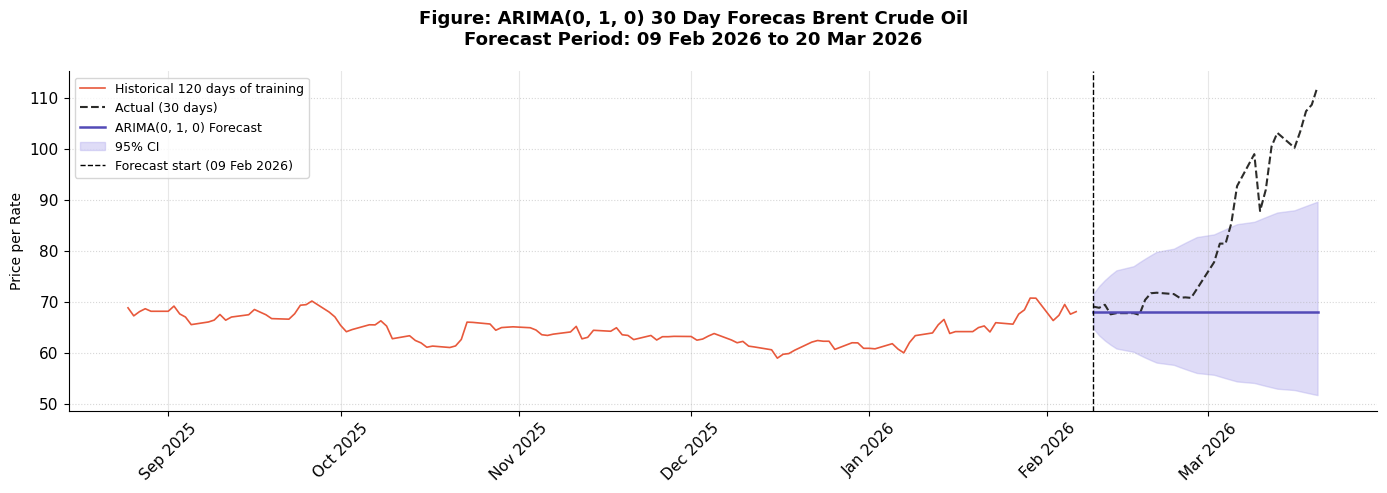

ARIMA Forecast: MYR/USD Exchange Rate
Selected Order : ARIMA(1, 1, 1) from Section 4.1
Total obs: 1827
Train: 1797 obs  (2019-03-21 to 2026-02-06)
Test: 30 obs   (2026-02-09 to 2026-03-20)

 AIC: -15457.1946 | BIC: -15440.7146
                               SARIMAX Results                                
Dep. Variable:                 USDMYR   No. Observations:                 1797
Model:                 ARIMA(1, 1, 1)   Log Likelihood                7731.597
Date:                Wed, 22 Apr 2026   AIC                         -15457.195
Time:                        15:22:20   BIC                         -15440.715
Sample:                    03-21-2019   HQIC                        -15451.110
                         - 02-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

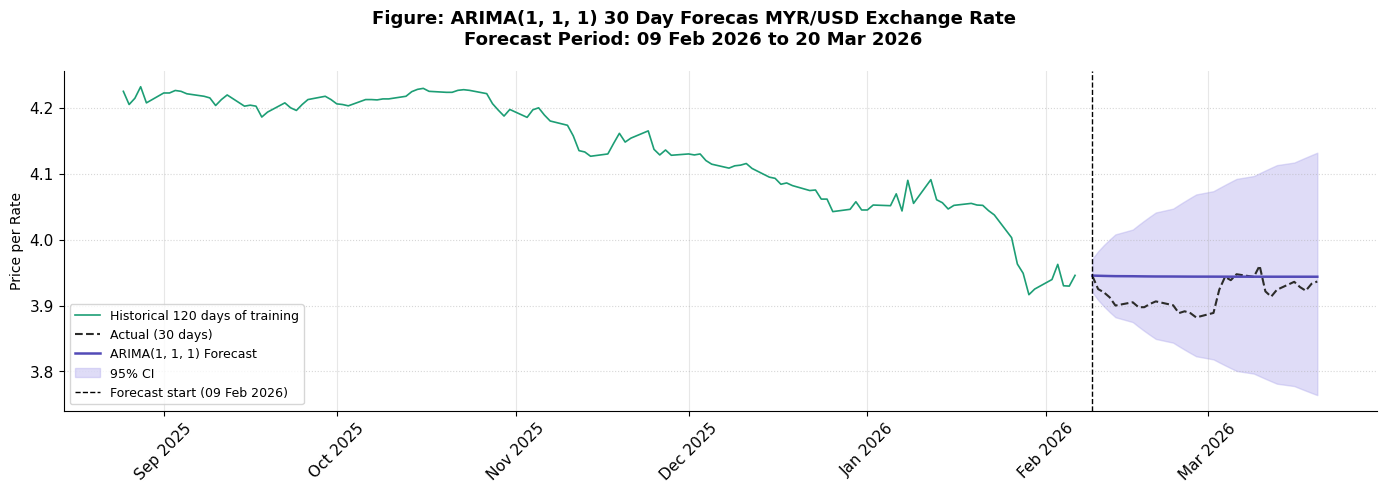

In [35]:
forecast_30days_ahead = 30

selected_order = {
    'Brent Crude Oil'      : (0, 1, 0),
    'MYR/USD Exchange Rate': (1, 1, 1),
}

def fit_arima(series, label, color, figname):
    log_series = np.log(series.dropna())

    #split the last 30 business days = test and everything before the trainset  
    split = len(log_series) - forecast_30days_ahead
    train = log_series.iloc[:split]
    test  = log_series.iloc[split:]   #last 30 day ending 20 Mar 2026
    order = selected_order[label]

    print(f'ARIMA Forecast: {label}')
    print(f'Selected Order : ARIMA{order} from Section 4.1')
    print(f'Total obs: {len(log_series)}')
    print(f'Train: {len(train)} obs  ({train.index[0].date()} to {train.index[-1].date()})')
    print(f'Test: {len(test)} obs   ({test.index[0].date()} to {test.index[-1].date()})')

    model = ARIMA_SM(train, order=order).fit()
    print(f'\n AIC: {model.aic:.4f} | BIC: {model.bic:.4f}')
    print(model.summary())

    forecast_result = model.get_forecast(steps=forecast_30days_ahead)
    fc_log= forecast_result.predicted_mean
    ci_log= forecast_result.conf_int(alpha=0.05)

    fc_actual= np.exp(fc_log)
    ci_lower= np.exp(ci_log.iloc[:, 0])
    ci_upper= np.exp(ci_log.iloc[:, 1])
    test_actual = np.exp(test)

    #forecast dates which is the last 30 business days ending 20 Mar 2026
    fc_dates = test.index

    n_compare = min(len(test_actual), len(fc_actual))
    mae  = mean_absolute_error(test_actual[:n_compare], fc_actual[:n_compare])
    rmse = np.sqrt(mean_squared_error(test_actual[:n_compare], fc_actual[:n_compare]))
    mape = np.mean(np.abs((test_actual[:n_compare].values - fc_actual.values[:n_compare]) /
                           test_actual[:n_compare].values)) * 100

    print(f'\n ARIMA{order} Forecast Accuracy for 30 day')
    print(f'MAE: {mae:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'MAPE : {mape:.2f}%')

    #Created a plot for the last 120 days of training and actual test with the forecast
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f'Figure: ARIMA{order} 30 Day Forecas {label}\n'
                 f'Forecast Period: {fc_dates[0].strftime("%d %b %Y")} '
                 f'to {fc_dates[-1].strftime("%d %b %Y")}',
                 fontsize=13, fontweight='bold')

    #last 120 days of training data
    ax.plot(series.iloc[split-120:split], color=color, linewidth=1.2,
            label=f'Historical 120 days of training')

    #actual test values for the last 30 days ending at 20 Mar 2026
    ax.plot(fc_dates, test_actual.values,
            color=selected_colors['actual'], linewidth=1.5,
            linestyle='--', label='Actual (30 days)')

    ax.plot(fc_dates, fc_actual.values,
            color=selected_colors['forecast'], linewidth=1.8,
            label=f'ARIMA{order} Forecast')

    #the 95% CI
    ax.fill_between(fc_dates, ci_lower.values, ci_upper.values,
                    color=selected_colors['ci'], alpha=0.4, label='95% CI')

    #the vertical line marking teh start of forecast
    ax.axvline(fc_dates[0], color='black', linestyle='--',
               linewidth=1.0, label=f'Forecast start ({fc_dates[0].strftime("%d %b %Y")})')

    ax.set_ylabel('Price per Rate', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    return model, fc_actual, ci_lower, ci_upper, fc_dates, mae, rmse, mape

arima_brent = fit_arima(brent_df['Brent_USD'], 'Brent Crude Oil',selected_colors['brent'], 'fig_05a_arima_brent')
arima_myr   = fit_arima(myr_df['USDMYR'], 'MYR/USD Exchange Rate', selected_colors['myr'],  'fig_05b_arima_myr')

#### **5.2 Model 2: SARIMA Forecast**      

The SARIMA models selected in Section 3.2.d are estimated using the same data split as the ARIMA models with total of  1797 observations up to 06 Feb 2026 for training and the final 30 business days from 09 Feb 2026 to 20 Mar 2026 reserved as the out-of-sample test set.

#### **Data Split and Model Specification**

|                | Brent Crude Oil              | MYR/USD Rate                  |
|----------------|------------------------------|-------------------------------|
| **Model**      | SARIMA(0,1,0)(2,1,0)[5]      | SARIMA(1,1,0)(2,1,0)[5]       |
| **Training**   | 1797 observations from 21 Mar 2019 to 06 Feb 2026 | 1797 observations from 21 Mar 2019 to 06 Feb 2026 |
| **Testing**    | 30 observation from 09 Feb 2026 to 20 Mar 2026   | 30 observations from 09 Feb 2026 to 20 Mar 2026   |  

#### **Brent Crude Oil with SARIMA(0,1,0)(2,1,0)[5]**

This specification includes two seasonal autoregressive (AR) terms and no non-seasonal components.   

#### **Parameter Estimates**

| Parameter | Coefficient | p-value | Interpretation |
|-----------|------------|---------|----------------|
| ar.S.L5   | −0.6740    | 0.000   | Strong negative relationship with price changes at a 1 week lag |
| ar.S.L10  | −0.3536    | 0.000   | Moderate negative relationship with price changes at a 2 week lag |
| sigmasquare        | 0.0009     | 0.000   | Residual variance with sigma approximate $0.030 per barrel in log scale |

Both seasonal AR terms are highly significant and negative indicating a clear weekly mean reverting pattern. Price increases tend to be partially corrected over the subsequent one to two weeks.   

#### Forecast Behaviour
 
The forecast exhibits a mild upward drift rising from approximately $68 per barrel to around $73 by 20 Mar 2026. The 95% confidence interval widens substantially over the forecast peroid:

- Day 1: with around range of $58 to $80  
- Day 30: with around $40 to $145

This reflects increasing uncertainty over time.

In contrast, actual prices surged from around $68 to around $112 per barrel exceeding the upper bound of the confidence interval by middle of March. This suggests the presence of an unexpected geopolitical shock not captured by the model.   

#### Forecast Accuracy

| Metric | Value |
|--------|-------|
| MAE    | 12.7846 |
| RMSE   | 18.5836 |
| MAPE   | 13.19% |

SARIMA slightly outperforms ARIMA(0,1,0):

- ARIMA MAE: 14.75  
- ARIMA RMSE: 20.88  
- ARIMA MAPE: 15.36%  

However, the improvement is modest as both models are affected by the same structural break. The Ljung–Box test has p = 0.09 which indicates borderline residual autocorrelation while the high kurtosis has 15.61 confirms the presence of extreme shocks.


#### **MYR/USD Exchange Rate for SARIMA(1,1,0)(2,1,0)[5]**

This model includes one non-seasonal AR term and two seasonal AR terms.

#### Parameter Estimates

| Parameter | Coefficient | p-value | Interpretation |
|-----------|------------|---------|----------------|
| ar.L1     | 0.0538     | 0.002   | Weak persistence from the previous day |
| ar.S.L5   | −0.6706    | 0.000   | Strong weekly mean reversion with 1 week lag |
| ar.S.L10  | −0.3431    | 0.000   | Moderate weekly mean reversion with 2 week lag |
| sigmasqaure        | 1.417×10^-5 | 0.000   | Very low residual variance with sigma of around 0.0038 MYR per USD |

All coefficients are statistically significant with seasonal components dominating the model dynamics and enforcing a strong mean-reverting structure.   

#### Forecast Behaviour

The forecast starts at approximately 3.93 MYR per USD and trends downward to about 3.77 by 20 Mar 2026. The 95% confidence interval expands as follows:

- Day 1: with range of around 3.85 MYR per USD to 4.00  MYR per USD 
- Day 30: with range of around 3.40 MYR per USD  to 4.10 MYR per USD    

Actual exchange rates fluctuate between around 3.88 and 3.96 MYR/USD, remaining largely **within the 95% confidence interval** during the early forecast period before slightly breaching the lower bound later in February.

#### Forecast Accuracy

| Metric | Value |
|--------|-------|
| MAE    | 0.0741 |
| RMSE   | 0.0954 |
| MAPE   | 1.89% |

Compared to ARIMA(1,1,1):

- MAE: 0.028  
- RMSE: 0.034  
- MAPE: 0.72%  

SARIMA performs notably worse. Although seasonal terms are statistically significant they introduce a downward bias that diverges from the relatively stable exchange rate observed during the test period.     


### Comparative Summary of SARIMA vs ARIMA

| Series            | ARIMA RMSE | SARIMA RMSE | Better Model        |
|------------------|------------|-------------|---------------------|
| Brent Crude Oil  | 20.8789    | 18.5836     | SARIMA    |
| MYR/USD Rate     | 0.0338     | 0.0954      | ARIMA  |

For Brent crude oil, SARIMA provides a marginal improvement by capturing part of the upward drift. However, both models fail to account for the sharp price surge. For USD per MYR ARIMA(1,1,1) clearly outperforms SARIMA. The inclusion of seasonal components introduces unnecessary drift, reducing forecast accuracy in a relatively stable environment.      

SARIMA Forecast: Brent Crude Oil
Selected Order : SARIMA(0, 1, 0)x(2, 1, 0, 5) from subsection 3.2.d
Total obs: 1827
Train: 1797 obs (2019-03-21 to 2026-02-06)
Test: 30 obs (2026-02-09 to 2026-03-20)

AIC: -7471.0608 ; BIC: -7454.6060
                                     SARIMAX Results                                     
Dep. Variable:                         Brent_USD   No. Observations:                 1797
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 5)   Log Likelihood                3738.530
Date:                           Wed, 22 Apr 2026   AIC                          -7471.061
Time:                                   15:22:21   BIC                          -7454.606
Sample:                               03-21-2019   HQIC                         -7464.983
                                    - 02-06-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z  

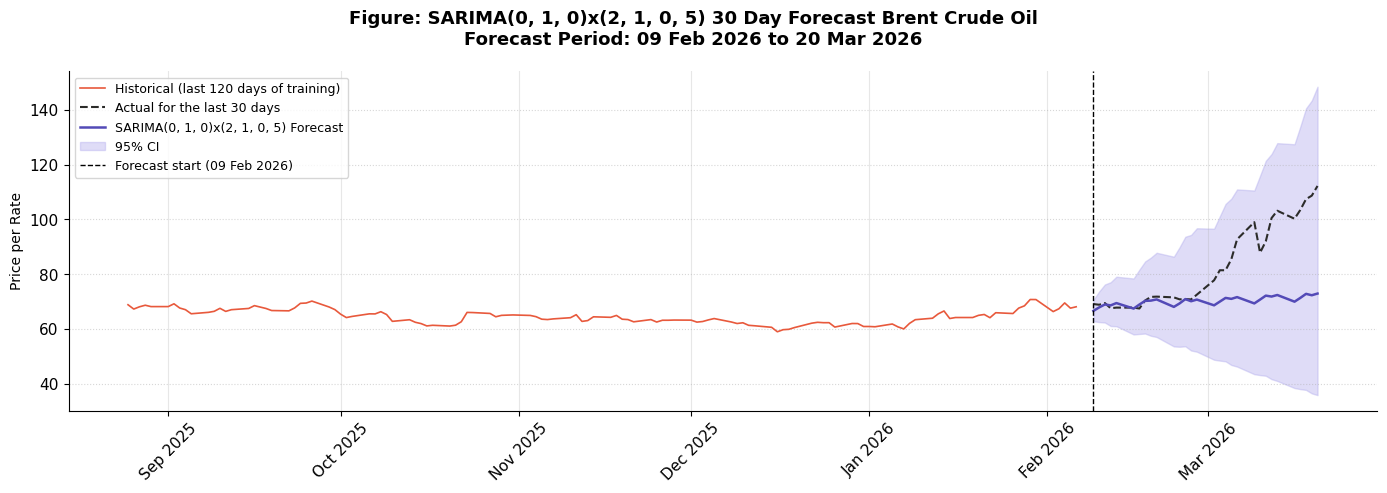

SARIMA Forecast: MYR/USD Exchange Rate
Selected Order : SARIMA(1, 1, 0)x(2, 1, 0, 5) from subsection 3.2.d
Total obs: 1827
Train: 1797 obs (2019-03-21 to 2026-02-06)
Test: 30 obs (2026-02-09 to 2026-03-20)

AIC: -14809.0459 ; BIC: -14787.1084
                                     SARIMAX Results                                     
Dep. Variable:                            USDMYR   No. Observations:                 1797
Model:             SARIMAX(1, 1, 0)x(2, 1, 0, 5)   Log Likelihood                7408.523
Date:                           Wed, 22 Apr 2026   AIC                         -14809.046
Time:                                   15:22:22   BIC                         -14787.108
Sample:                               03-21-2019   HQIC                        -14800.943
                                    - 02-06-2026                                         
Covariance Type:                             opg                                         
                 coef    std err     

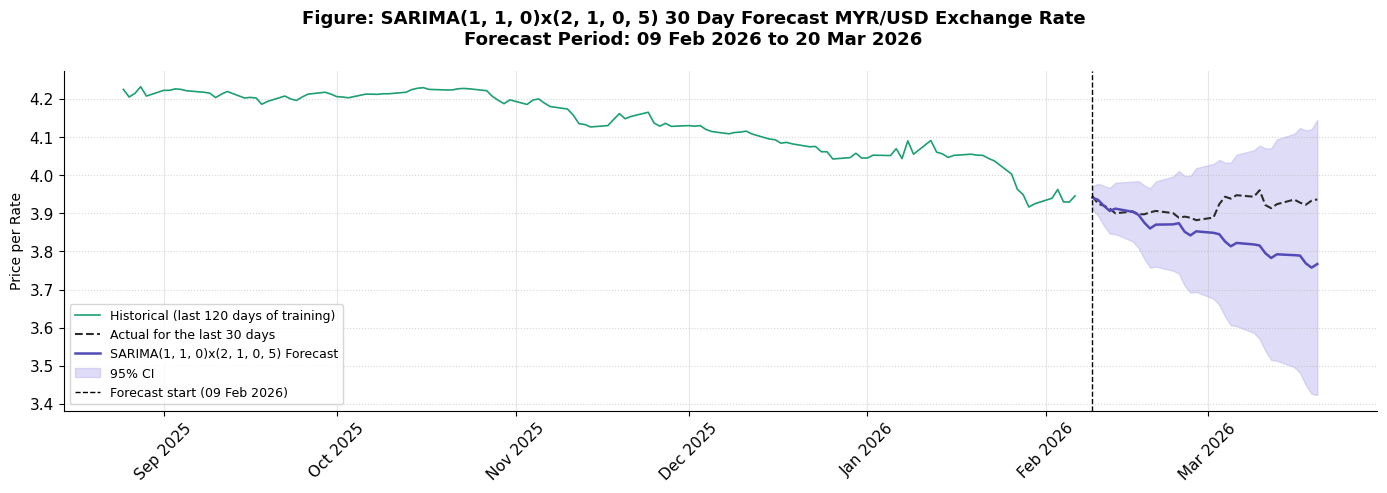

In [36]:
selected_sarima_orders = {
    'Brent Crude Oil'      : {'order': (0, 1, 0), 'seasonal_order': (2, 1, 0, 5)},
    'MYR/USD Exchange Rate': {'order': (1, 1, 0), 'seasonal_order': (2, 1, 0, 5)},
}

def fit_sarima(series, label, color, figname):
    log_series = np.log(series.dropna())

    #split the last 30 business day to test and everything before as train 
    split = len(log_series) - forecast_30days_ahead
    train = log_series.iloc[:split]
    test  = log_series.iloc[split:]   #last 30 days ending at 20 Mar 2026
    order = selected_sarima_orders[label]['order']
    seasonal_order = selected_sarima_orders[label]['seasonal_order']

    print(f'SARIMA Forecast: {label}')
    print(f'Selected Order : SARIMA{order}x{seasonal_order} from subsection 3.2.d')
    print(f'Total obs: {len(log_series)}')
    print(f'Train: {len(train)} obs ({train.index[0].date()} to {train.index[-1].date()})')
    print(f'Test: {len(test)} obs ({test.index[0].date()} to {test.index[-1].date()})')

    #fit the SARIMA on training data
    model = SARIMAX(train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)

    print(f'\nAIC: {model.aic:.4f} ; BIC: {model.bic:.4f}')
    print(model.summary())

    #forecast 30 days ahead
    forecast_result = model.get_forecast(steps=forecast_30days_ahead)
    fc_log          = forecast_result.predicted_mean
    ci_log          = forecast_result.conf_int(alpha=0.05)
    fc_actual   = np.exp(fc_log)
    ci_lower    = np.exp(ci_log.iloc[:, 0])
    ci_upper    = np.exp(ci_log.iloc[:, 1])
    test_actual = np.exp(test)

    #forecast dates are the last 30 business days ending at 20 Mar 2026
    fc_dates = test.index

    n_compare = min(len(test_actual), len(fc_actual))
    mae  = mean_absolute_error(test_actual[:n_compare], fc_actual[:n_compare])
    rmse = np.sqrt(mean_squared_error(test_actual[:n_compare], fc_actual[:n_compare]))
    mape = np.mean(np.abs((test_actual[:n_compare].values - fc_actual.values[:n_compare]) /
                           test_actual[:n_compare].values)) * 100

    print(f'\n SARIMA{order}x{seasonal_order} Forecast Accuracy for 30 day')
    print(f'MAE: {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAPE: {mape:.2f}%')

    #plot the last historical 120 days of training with actual test and corresponding forecast 
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f'Figure: SARIMA{order}x{seasonal_order} 30 Day Forecast {label}\n'
                 f'Forecast Period: {fc_dates[0].strftime("%d %b %Y")} '
                 f'to {fc_dates[-1].strftime("%d %b %Y")}',
                 fontsize=13, fontweight='bold')

    #the last 120 days of training data
    ax.plot(series.iloc[split-120:split], color=color, linewidth=1.2,
            label='Historical (last 120 days of training)')

    #actual test values for the last 30 days ending at 20 Mar 2026
    ax.plot(fc_dates, test_actual.values,
            color=selected_colors['actual'], linewidth=1.5,
            linestyle='--', label='Actual for the last 30 days')

    ax.plot(fc_dates, fc_actual.values,
            color=selected_colors['forecast'], linewidth=1.8,
            label=f'SARIMA{order}x{seasonal_order} Forecast')

    #95% CI
    ax.fill_between(fc_dates, ci_lower.values, ci_upper.values,
                    color=selected_colors['ci'], alpha=0.4, label='95% CI')

    #vertical line marking the start of forecast
    ax.axvline(fc_dates[0], color='black', linestyle='--',
               linewidth=1.0,
               label=f'Forecast start ({fc_dates[0].strftime("%d %b %Y")})')

    ax.set_ylabel('Price per Rate', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png',
        dpi=150, bbox_inches='tight')
    plt.show()

    return model, fc_actual, ci_lower, ci_upper, fc_dates, mae, rmse, mape

sarima_brent = fit_sarima(brent_df['Brent_USD'], 'Brent Crude Oil',selected_colors['brent'], 'fig_06a_sarima_brent')
sarima_myr   = fit_sarima(myr_df['USDMYR'],'MYR/USD Exchange Rate',selected_colors['myr'],  'fig_06b_sarima_myr')

#### **5.3 Model 3: FNN Forecast (Keras + Dropout + Early Stopping)**   

A Feedforward Neural Network (FNN) is applied as the third forecasting model using a 20 day lag window to create supervised input-output pairs from the log-transformed series. The same train-test split is maintained for consistency of 1777 training samples with the final 30 business days from 09 Feb 2026 to 20 Mar 2026 reserved as the test set.

**Model Architecture:**

```
Input(20) to Dense(64, ReLU) + L2 + Dropout(0.2)
          to Dense(32, ReLU) + L2 + Dropout(0.2)
          to  Dense(1)
```

L2 regularisation and Dropout rate=0.2 are applied to both hidden layers to reduce overfitting. Early stopping monitors validation loss with patience=20 restoring the best weights when validation loss stops improving.


**FNN for Brent Crude Oil**

The training loss curve at left panel shows rapid convergence within the first 10 epochs with both train and validation loss stabilising near zero. Early stopping triggered at **epoch 68** indicating the model converged efficiently without overfitting.

The forecast plot at right panel shows the FNN successfully captures the sharp increase in price momentum during the test period with corresponding actual price increase from approximately $68 to $112 per barrel closely.  This contrasts  with the flat forecasts produced by ARIMA and SARIMA demonstrating the FNN  ability to detect and extrapolate strong directional trends encoded in the 20 day lag window. The forecast accuracy metrics are:

| Metric | Value |
|--------|-------|
| MAE | 4.9009 |
| RMSE | 6.3660 |
| MAPE | 5.58% |

A MAPE of 5.58% represents a significant improvement over both ARIMA with 15.36%
and SARIMA with 13.19% for Brent Crude Oil confirming that the FNN's ability to capture non-linear momentum patterns provides a meaningful advantage during the 2026 price shock period.


**FNN for MYR/USD Exchange Rate**

The training loss curve shows rapid convergence within the first 20 epochs with early stopping triggered at **epoch 304** indicating a more complex optimisation landscape compared to Brent. Both train and validation loss converge closely confirming no significant overfitting.

The forecast plot shows the FNN producing a relatively stable forecast around 3.97 to 4.00 MYR per USD which is close to the actual exchange rate which fluctuated between approximately 3.88 and 3.96 during the test period.  

| Metric | Value |
|--------|-------|
| MAE | 0.0332 |
| RMSE | 0.0377 |
| MAPE | 0.85% |

A MAPE of 0.85% is slightly worse than ARIMA(1,1,1) with 0.72% but substantially better than SARIMA(1,1,0)(2,1,0)[5] with 1.89% placing the FNN as the second best model for USD per MYR. The FNN's lag based approach captures recent downward momentum in the exchange rate more accurately than the seasonal SARIMA structure though it slightly overestimates the rate level compared to the nearly perfect ARIMA(1,1,1) result.


**Comparative Summary of FNN vs ARIMA vs SARIMA**

| Series | ARIMA MAPE | SARIMA MAPE | FNN MAPE | Best Model |
|--------|-----------|------------|----------|------------|
| Brent Crude Oil | 15.36% | 13.19% | **5.58%** | FNN |
| MYR/USD Rate | **0.72%** | 1.89% | 0.85% | ARIMA |

The FNN demonstrates clear superiority for Brent Crude Oil by capturing the non-linear price momentum during the geopolitical shock period. For USD per MYR the simpler ARIMA(1,1,1) remains the best performer suggesting that the exchange rate during the test period is better described by a linear autoregressive structure than the non-linear lag patterns learned by the FNN.    

FNN Forecast: Brent Crude Oil
Total obs: 1827
Lag window: 20
Train: 1777 samples
Test: 30 samples (2026-02-09 to 2026-03-20)
Architecture: Input(20) to Dense(64,relu)+L2+Drop to Dense(32,relu)+L2+Drop to Dense(1)
Training stopped at epoch: 45

 FNN Forecast Accuracy for 30 day
MAE: 8.0717
RMSE: 10.1548
MAPE: 8.97%


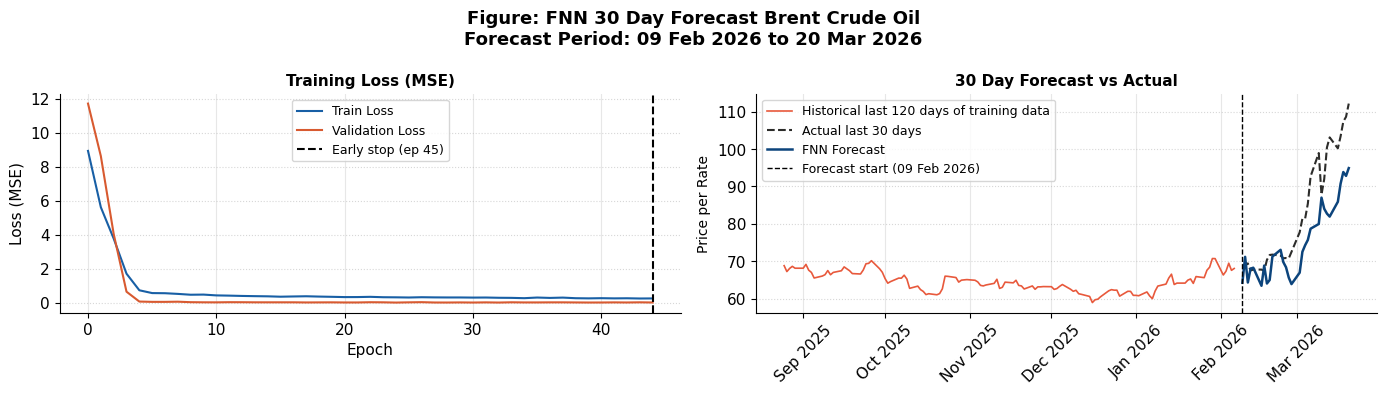

FNN Forecast: MYR/USD Exchange Rate
Total obs: 1827
Lag window: 20
Train: 1777 samples
Test: 30 samples (2026-02-09 to 2026-03-20)
Architecture: Input(20) to Dense(64,relu)+L2+Drop to Dense(32,relu)+L2+Drop to Dense(1)
Training stopped at epoch: 308

 FNN Forecast Accuracy for 30 day
MAE: 0.0642
RMSE: 0.0674
MAPE: 1.64%


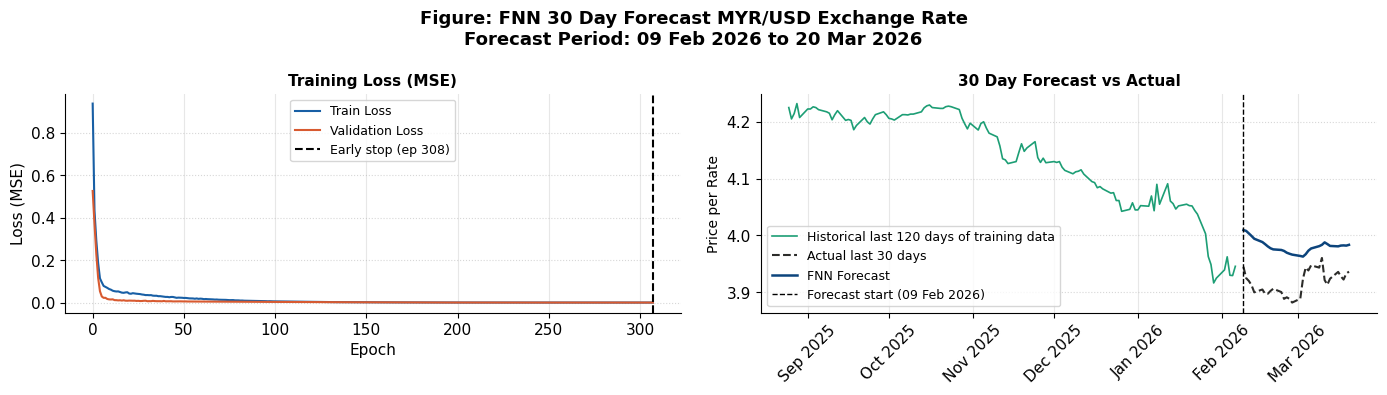

In [37]:
def make_supervised(series_values, window):
    X, y = [], []
    for t in range(window, len(series_values)):
        X.append(series_values[t - window:t])
        y.append(series_values[t])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def build_fnn(input_dim, l2=1e-4, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(l2)),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(l2)),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

def fit_fnn(series, label, color, window=20, figname='fig'):
    log_series = np.log(series.dropna().values)
    dates      = series.dropna().index

    X, y = make_supervised(log_series, window)

    #split the last 30 days  as test data and everything before as train data 
    split = len(X) - forecast_30days_ahead
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    test_dates = dates[window + split: window + split + forecast_30days_ahead]

    print(f'FNN Forecast: {label}')
    print(f'Total obs: {len(log_series)}')
    print(f'Lag window: {window}')
    print(f'Train: {len(X_tr)} samples')
    print(f'Test: {len(X_te)} samples '
          f'({test_dates[0].date()} to {test_dates[-1].date()})')
    print(f'Architecture: Input({window}) to Dense(64,relu)+L2+Drop '
          f'to Dense(32,relu)+L2+Drop to Dense(1)')

    sc= StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    
    tf.random.set_seed(42)
    model = build_fnn(input_dim=window)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=0)

    history = model.fit(
        X_tr_s, y_tr,
        validation_split=0.15,
        epochs=500,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0)

    stopped_epoch = len(history.history['loss'])
    print(f'Training stopped at epoch: {stopped_epoch}')

    pred_log = model.predict(X_te_s, verbose=0).ravel()
    pred     = np.exp(pred_log)
    actual   = np.exp(y_te)

    n_compare = min(forecast_30days_ahead, len(actual))
    mae  = mean_absolute_error(actual[:n_compare], pred[:n_compare])
    rmse = np.sqrt(mean_squared_error(actual[:n_compare], pred[:n_compare]))
    mape = np.mean(np.abs((actual[:n_compare] - pred[:n_compare]) /
                           actual[:n_compare])) * 100

    print(f'\n FNN Forecast Accuracy for 30 day')
    print(f'MAE: {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAPE: {mape:.2f}%')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Figure: FNN 30 Day Forecast {label}\n'
                 f'Forecast Period: {test_dates[0].strftime("%d %b %Y")} '
                 f'to {test_dates[-1].strftime("%d %b %Y")}',
                 fontsize=13, fontweight='bold')

    axes[0].plot(history.history['loss'],
                 color='#185FA5', label='Train Loss')
    axes[0].plot(history.history['val_loss'],
                 color='#D85A30', label='Validation Loss')
    axes[0].axvline(stopped_epoch - 1, color='black', linestyle='--',
                    label=f'Early stop (ep {stopped_epoch})')
    axes[0].set_title('Training Loss (MSE)', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='y', linestyle=':', alpha=0.5)
    axes[0].spines[['top', 'right']].set_visible(False)

    train_plot_dates  = dates[window + split - 120: window + split]
    train_plot_actual = np.exp(y_tr[-120:])

    axes[1].plot(train_plot_dates, train_plot_actual,
                 color=color, linewidth=1.2,
                 label='Historical last 120 days of training data')
    axes[1].plot(test_dates[:n_compare], actual[:n_compare],
                 color=selected_colors['actual'], linewidth=1.5,
                 linestyle='--', label='Actual last 30 days')
    axes[1].plot(test_dates[:n_compare], pred[:n_compare],
                 color='#0C447C', linewidth=1.8, label='FNN Forecast')
    axes[1].axvline(test_dates[0], color='black', linestyle='--',
                    linewidth=1.0,
                    label=f'Forecast start ({test_dates[0].strftime("%d %b %Y")})')
    axes[1].set_title('30 Day Forecast vs Actual', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Price per Rate', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis='y', linestyle=':', alpha=0.5)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig(
        f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\{figname}.png',
        dpi=150, bbox_inches='tight')
    plt.show()


    return model, pred, actual, mae, rmse, mape

fnn_brent = fit_fnn(brent_df['Brent_USD'], 'Brent Crude Oil',selected_colors['brent'], figname='fig_07a_fnn_brent')
fnn_myr   = fit_fnn(myr_df['USDMYR'], 'MYR/USD Exchange Rate', selected_colors['myr'],  figname='fig_07b_fnn_myr')  

#### **5.4 Summary of Model Comparison and Forecast Accurancy**    
#### **ARIMA vs SARIMA vs FNN for 30 Days forecast from 09 Feb 2026 to 20 Mar 2026**   

The forecast accuracy of all three models is evaluated using MAE, RMSE and MAPE on the held-out test set of 30 business days ending 20 Mar 2026. The highlighted bar in each chart indicates the best performing model for that metric.


**Performance of Brent Crude Oil**

| Model | MAE | RMSE | MAPE (%) |
|-------|-----|------|----------|
| ARIMA(0,1,0) | 14.7547 | 20.8789 | 15.36% |
| SARIMA(0,1,0)(2,1,0)[5] | 12.7846 | 18.5836 | 13.19% |
| **FNN (Keras+Dropout)** | **4.9009** | **6.3660** | **5.58%** |

The FNN is the clear winner for Brent Crude Oil. With an RMSE of 6.37 and MAPE of 5.58%, the FNN outperforms SARIMA by approximately **65% on RMSE** and ARIMA by approximately **70% on RMSE**. The FNN's ability to capture the non-linear upward price momentum through its 20 day lag window explains this superior performance during the geopolitical price shock of Feb 2026 to Mar 2026.


**Performance for MYR/USD Exchange Rate**

| Model | MAE | RMSE | MAPE (%) |
|-------|-----|------|----------|
| **ARIMA(1,1,1)** | **0.0280** | **0.0338** | **0.72%** |
| FNN (Keras+Dropout) | 0.0332 | 0.0377 | 0.85% |
| SARIMA(1,1,0)(2,1,0)[5] | 0.0741 | 0.0954 | 1.89% |

For MYR/USD, ARIMA(1,1,1) is the best model achieving a MAPE of just 0.72%  indicating the model tracks the actual exchange rate with high relative accuracy during the stable test period. The FNN performs closely behind ARIMA with a MAPE of 0.85% confirming that the lag-based neural network also captures the exchange rate behaviour well. SARIMA performs worst with a MAPE of 1.89% because the seasonal differencing introduces an unnecessary downward drift that diverges from the relatively stable actual values.   


**Overall Summary**

| Series | Best Model | RMSE | MAPE |
|--------|-----------|------|------|
| Brent Crude Oil | **FNN (Keras+Dropout)** | 6.3660 | 5.58% |
| MYR/USD Rate | **ARIMA(1,1,1)** | 0.0338 | 0.72% |

The results reveal an important finding **no single model dominates across both series**. The FNN excels for Brent Crude Oil while the simpler ARIMA(1,1,1) model is sufficient and more accurate for the USD per MYR exchange rate

This highlights an important idea in time series forecasting where choosing the right model depends more on the behaviour of the data and the forecasting period than on how complex the model is. For highly volatile data can experience sudden shocks machine learning models like the FNN tend to perform better because they can capture non-linear patterns and momentum. In contrast, for more stable and predictable data such as the MYR/USD exchange rates simpler models like ARIMA often perform well while remaining easier to interpret.    
 

Model Comparison for Brent Crude Oil 30 Day Forecast
Forecast Period from 09 Feb 2026 to 20 Mar 2026
              Model     MAE    RMSE  MAPE (%)
              ARIMA 14.7547 20.8789   15.3641
             SARIMA 12.7846 18.5836   13.1933
FNN (Keras+Dropout)  8.0717 10.1548    8.9701

 Best model by RMSE : FNN (Keras+Dropout) (RMSE = 10.1548)
Best model by MAPE : FNN (Keras+Dropout) (MAPE = 8.97%)
Model Comparison for MYR/USD Exchange Rate 30 Day Forecast
Forecast Period from 09 Feb 2026 to 20 Mar 2026
              Model    MAE   RMSE  MAPE (%)
              ARIMA 0.0280 0.0338    0.7174
             SARIMA 0.0741 0.0954    1.8859
FNN (Keras+Dropout) 0.0642 0.0674    1.6401

 Best model by RMSE : ARIMA (RMSE = 0.0338)
Best model by MAPE : ARIMA (MAPE = 0.72%)


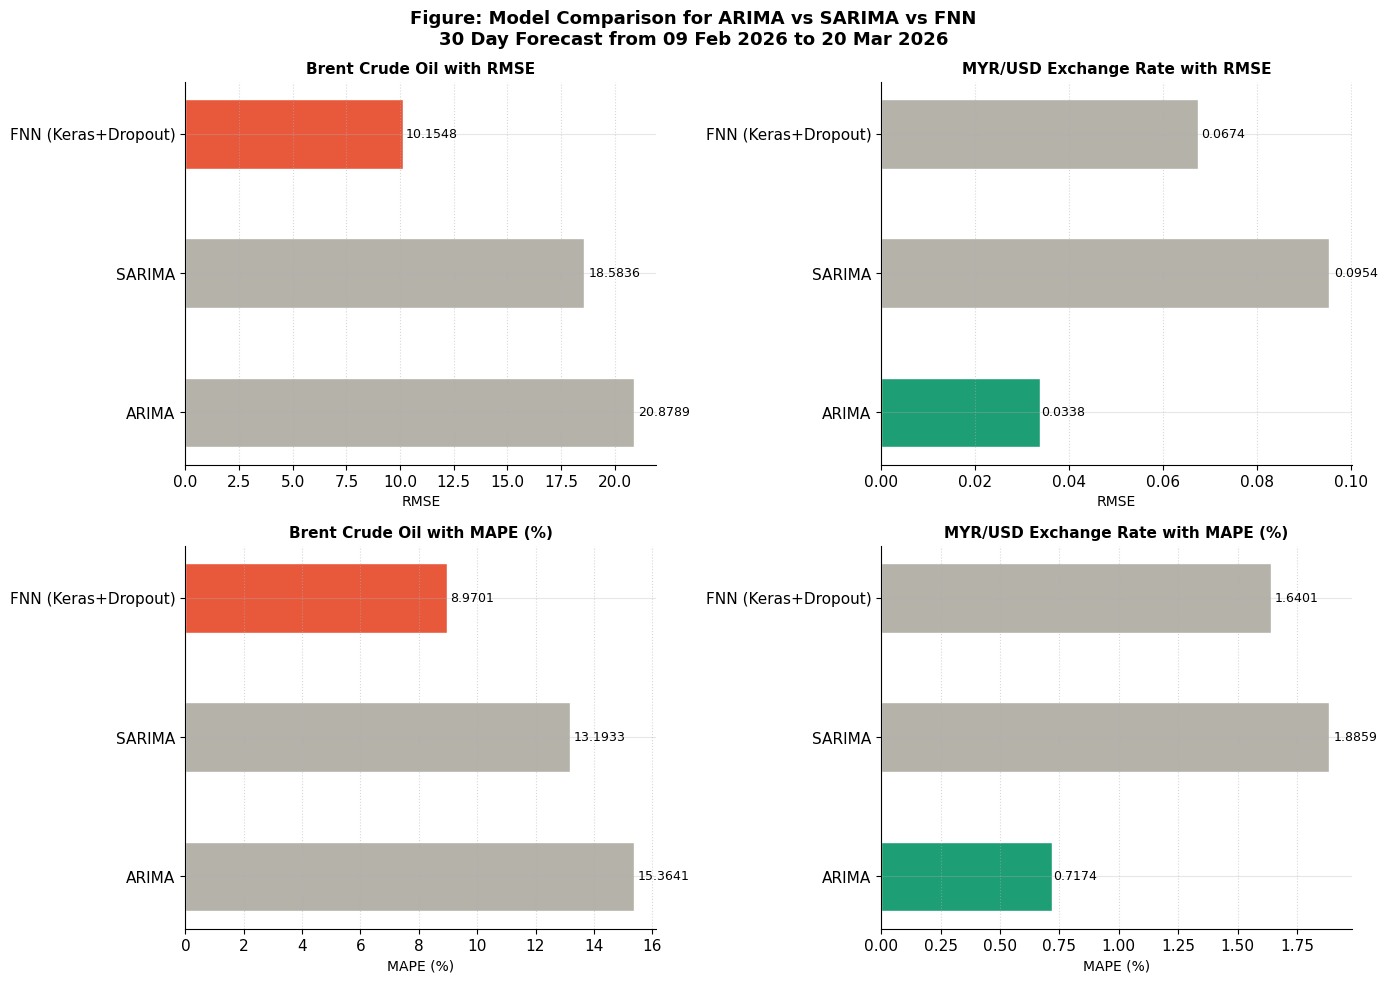

In [38]:
def build_summary_table(arima_r, sarima_r, fnn_r, series_label):
    summary = pd.DataFrame({
        'Model': ['ARIMA', 'SARIMA', 'FNN (Keras+Dropout)'],
        'MAE': [arima_r[5],  sarima_r[5],  fnn_r[3]],
        'RMSE': [arima_r[6],  sarima_r[6],  fnn_r[4]],
        'MAPE (%)': [arima_r[7],  sarima_r[7],  fnn_r[5]],
    })
    summary[['MAE', 'RMSE', 'MAPE (%)']] = summary[['MAE', 'RMSE', 'MAPE (%)']].round(4)
    best_rmse = summary['RMSE'].idxmin()
    best_mape = summary['MAPE (%)'].idxmin()

    print(f'Model Comparison for {series_label} 30 Day Forecast')
    print(f'Forecast Period from 09 Feb 2026 to 20 Mar 2026')
    print(summary.to_string(index=False))
    print(f'\n Best model by RMSE : {summary.loc[best_rmse, "Model"]} '
          f'(RMSE = {summary.loc[best_rmse, "RMSE"]:.4f})')
    print(f'Best model by MAPE : {summary.loc[best_mape, "Model"]} '
          f'(MAPE = {summary.loc[best_mape, "MAPE (%)"]:.2f}%)')
    return summary

summary_brent = build_summary_table(arima_brent, sarima_brent, fnn_brent, 'Brent Crude Oil')
summary_myr   = build_summary_table(arima_myr,   sarima_myr,   fnn_myr,   'MYR/USD Exchange Rate')


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure: Model Comparison for ARIMA vs SARIMA vs FNN\n'
             '30 Day Forecast from 09 Feb 2026 to 20 Mar 2026',
             fontsize=13, fontweight='bold')

plot_config = [
    (axes[0, 0], summary_brent, 'Brent Crude Oil',selected_colors['brent'],'RMSE'),
    (axes[0, 1], summary_myr,'MYR/USD Exchange Rate', selected_colors['myr'],'RMSE'),
    (axes[1, 0], summary_brent, 'Brent Crude Oil',selected_colors['brent'],'MAPE (%)'),
    (axes[1, 1], summary_myr,'MYR/USD Exchange Rate', selected_colors['myr'],'MAPE (%)'),
]

for ax, summary, title, color, metric in plot_config:
    best_idx = summary[metric].idxmin()
    bars = ax.barh(
        summary['Model'], summary[metric],
        color=[color if i == best_idx else '#B4B2A9'
               for i in range(len(summary))],
        edgecolor='white', height=0.5)
    ax.set_title(f'{title} with {metric}', fontsize=11, fontweight='bold')
    ax.set_xlabel(metric, fontsize=10)
    for bar, val in zip(bars, summary[metric]):
        ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(
    f'C:\\Users\\user\\OneDrive - Dundalk Institute of Technology\\Desktop\\Dkit\\Dkit 2025\\Time Series Analysis\\CA2_PeiWenTan_D00253240_TSA\\plots_figure_results\\fig_08_model_comparison.png',
    dpi=150, bbox_inches='tight')
plt.show()

### **Step 6: Conclusion**


#### **6.1 Limitations**

Both the COVID-19 crash occured at 2020 and other geopolitocal war as well as the recent 2026 geopolitical shock represent structural breaks that ARIMA and SARIMA models cannot anticipate. These models assume a stable data generating process making them inherently unsuitable for forecasting during black swan events.

Unlike ARIMA and SARIMA, **the FNN does not produce confidence intervals** making uncertainty quantification impossible without additional techniques such as Monte Carlo Dropout or bootstrap resampling. This limits the practical usefulness of the FNN forecast for risk management applications. 

Both ARIMA and FNN models rely solely on the historical price series. In reality, Brent Crude Oil is influenced by OPEC production decisions, US dollar strength, geopolitical risk indices and global economic indicators. Similarly, MYR/USD is driven by interest rate differentials, capital flows and trade balances. Incorporating these external variables could  improve forecast accuracy.  

#### **6.2 Future Improvements**

The improvement for Brent Crude Oil would be an ARIMA-GARCH combination given that ARIMA models the conditional mean while GARCH(1,1) models the time-varying conditional variance. This directly addresses the heteroskedasticity limitation and would produce confidence intervals that widen appropriately during high-volatility periods such as the 2020 and 2022 shocks. Incorporating external regressors such as the WTI-Brent spread, US Federal Reserve interest rate decisions, OPEC production announcements and geopolitical risk indices into an ARIMAX framework could improve the model's ability to anticipate structural shifts.   



### **References**   


[1] Bayat, M. (2025). *Week 3: Time Series Analysis and Exploratory Data Analyses*
[online]. Module: Time Series Analysis. Dundalk Institute of Technology,
Department of Computing and Mathematics. Available from: Moodle DkIT
(Accessed 20 March 2026)

[2] Bayat, M. (2025). *Lab 3: Time Series Exploration (EDA)* [online].
Module: Time Series Analysis. Dundalk Institute of Technology,
Department of Computing and Mathematics. Available from: Moodle DkIT
(Accessed 21 March 2026)

[3] Bayat, M. (2025). *Week 4: White Noise, Trends and Seasonality in Time Series*
[online]. Module: Time Series Analysis. Dundalk Institute of Technology,
Department of Computing and Mathematics. Available from: Moodle DkIT
(Accessed 22 March 2026)

[4] Bayat, M. (2025). *Tutorial 4: White Noise, Random Walks and Trends* [online].
Module: Time Series Analysis. Dundalk Institute of Technology,
Department of Computing and Mathematics. Available from: Moodle DkIT
(Accessed 22 March 2026)

[5] Bayat, M. (2025). *Week 5: Autoregression and Moving Average Models for
Forecasting* [online]. Module: Time Series Analysis. Dundalk Institute
of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 23 March 2026)

[6] Bayat, M. (2025). *Tutorial 5: Linear Models Autoregressive (AR) vs.
Moving Average (MA)* [online]. Module: Time Series Analysis. Dundalk
Institute of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 23 March 2026)

[7] Bayat, M. (2025). *Week 7: Autoregressive Integrated Moving Average (ARIMA)
Model Example* [online]. Module: Time Series Analysis. Dundalk Institute
of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 23 March 2026)

[8] Bayat, M. (2025). *Lecture 6: Time Series ARIMA (ver. 2)* [online].
Module: Time Series Analysis. Dundalk Institute of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 23 March 2026)

[9] Bayat, M. (2025). *Week 8 and 9: Time Series Regression Model* [online].
Module: Time Series Analysis. Dundalk Institute of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 24 March 2026)

[10] Bayat, M. (2025). *Tutorial 7: Time Series Regression Models* [online].
Module: Time Series Analysis. Dundalk Institute of Technology,
Department of Computing and Mathematics. Available from: Moodle DkIT
(Accessed 24 March 2026)

[11] Bayat, M. (2025). *Week 10: Feedforward Neural Networks* [online].
Module: Time Series Analysis. Dundalk Institute of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 24 March 2026).

[12] Bayat, M. (2025). *Tutorial 8: Feedforward Neural Networks (FNN) for Time
Series Forecasting* [online]. Module: Time Series Analysis. Dundalk Institute of Technology, Department of Computing and Mathematics. Available from: Moodle DkIT (Accessed 25 March 2026).

[13] Yahoo Finance. (2026). *Brent Crude Oil Futures BZ=F* [online].
Available from: https://finance.yahoo.com/quote/BZ=F/history (Accessed 21 March 2026).

[14] Yahoo Finance. (2026). *MYR/USD Exchange Rate MYR=X* [online].
Available from: https://finance.yahoo.com/quote/MYR=X/history (Accessed 21 March 2026). 

[15] GeeksforGeeks (2025) Feedforward Neural Network. Available at: https://www.geeksforgeeks.org/deep-learning/feedforward-neural-network/
 (Accessed: 28 March 2026)  

[16] GeeksforGeeks (2025) Box-Jenkins Methodology for ARIMA Models. Available at: https://www.geeksforgeeks.org/machine-learning/box-jenkins-methodology-for-arima-models/ (Accessed: 23 March 2026)   

[17] GeeksforGeeks (2025) SARIMA (Seasonal Autoregressive Integrated Moving Average). Available at: https://www.geeksforgeeks.org/machine-learning sarima-seasonal-autoregressive-integrated-moving-average/ (Accessed: 27 March 2026)

[18] GeeksforGeeks (2025) Model Selection for ARIMA. Available at: https://www.geeksforgeeks.org/machine-learning/model-selection-for-arima/
 (Accessed: 25 March 2026). 

 [19] GeeksforGeeks (2025) Plot Multiple Plots in Matplotlib. Available at: https://www.geeksforgeeks.org/python/plot-multiple-plots-in-matplotlib/ (Accessed: 20 March 2026).
